# Norway Future Skills — Digital and AI Skill Analysis

## Objective

This notebook builds on the data-quality and skill-demand notebooks to examine the **digital and AI-related segment of the current Norwegian job-posting sample**.

The project began with the broader question:

> **How is AI changing the Norwegian labor market, and what skills will matter in the future?**

The available data is a current sample rather than a historical before/after dataset. Therefore, this notebook does **not** claim that AI caused labor-market change over time. Instead, it measures:

1. which observed skills can be classified as digital using an external labor-market taxonomy
2. how frequently digital skills appear in the current sample
3. which jobs and cities are associated with digital-skill demand
4. which observed skills are specifically linked to artificial intelligence
5. which complementary digital skills appear disproportionately often in AI-linked jobs

## Methodological strategy

The analysis separates **exploration** from **classification**:

- multilingual semantic clustering is used only to explore the skill vocabulary
- ESCO is used as the external reference for final digital-skill classification
- exact ESCO matches form a high-confidence **core** set
- validated context-aware matches form a broader **expanded** set
- AI-linked demand is analyzed separately from general digital demand

This distinction helps avoid treating every skill in a mixed semantic cluster as digital or AI-related.


## 1. Load the prepared job–skill dataset

The previous notebook saved a long-format dataset in which each row represents one skill associated with one job posting.

Main fields used here:

- `job_id`
- `skill`
- `title`
- `category`
- `city`

The source `occupation` field is not used as a primary variable because the data-quality notebook showed that it has poor coverage and malformed values.


In [1]:
# Cell 03 — Load libraries and prepared job-skill data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

skills_jobs_df = pd.read_csv(
    "../data/processed/skills_jobs_analysis.csv"
)

display(skills_jobs_df.head())


,job_id,skills,skill,city,category,occupation,title
0,0112ac82-d16e-449b-8ae0-17e5bb874829,"Arkiv, Brukerstøtte, Digitalisering, Dokumenta...",Arkiv,LØRENSKOG,Not classified,Not classified,Vil du være med å styrke vår informasjonsforva...
1,0112ac82-d16e-449b-8ae0-17e5bb874829,"Arkiv, Brukerstøtte, Digitalisering, Dokumenta...",Brukerstøtte,LØRENSKOG,Not classified,Not classified,Vil du være med å styrke vår informasjonsforva...
2,0112ac82-d16e-449b-8ae0-17e5bb874829,"Arkiv, Brukerstøtte, Digitalisering, Dokumenta...",Digitalisering,LØRENSKOG,Not classified,Not classified,Vil du være med å styrke vår informasjonsforva...
3,0112ac82-d16e-449b-8ae0-17e5bb874829,"Arkiv, Brukerstøtte, Digitalisering, Dokumenta...",Dokumentasjonsforvaltning,LØRENSKOG,Not classified,Not classified,Vil du være med å styrke vår informasjonsforva...
4,0112ac82-d16e-449b-8ae0-17e5bb874829,"Arkiv, Brukerstøtte, Digitalisering, Dokumenta...",Informasjonsforvaltning,LØRENSKOG,Not classified,Not classified,Vil du være med å styrke vår informasjonsforva...


In [2]:
# Cell 04 — Validate the analysis dataset

print(
    f"Shape: {skills_jobs_df.shape[0]:,} rows × "
    f"{skills_jobs_df.shape[1]} columns"
)

print(
    "Unique jobs:",
    f"{skills_jobs_df['job_id'].nunique():,}"
)

print(
    "Unique skills:",
    f"{skills_jobs_df['skill'].nunique():,}"
)

display(
    skills_jobs_df[
        ["job_id", "skill", "title", "category", "city"]
    ]
    .isna()
    .sum()
    .rename("missing_values")
    .to_frame()
)


Shape: 95,324 rows × 7 columns
Unique jobs: 10,000
Unique skills: 10,997


,missing_values
job_id,0
skill,0
title,0
category,0
city,0


### Interpretation

Each row is a **job–skill relationship**, not a unique job posting.

Therefore:

- skill demand is measured with unique `job_id` counts
- job demand is also measured with unique `job_id` counts
- raw row counts are used only when explicitly describing job–skill relationships


## 2. Build the full skill vocabulary

We create one row per observed skill and calculate how many unique job postings contain it.

Rare skills are kept in the final analysis because specialized or emerging technical skills may appear infrequently.


In [3]:
# Cell 07 — Create the skill vocabulary

skill_vocabulary = (
    skills_jobs_df
    .groupby("skill")
    .agg(
        job_frequency=("job_id", "nunique")
    )
    .reset_index()
    .sort_values(
        "job_frequency",
        ascending=False
    )
)

print(
    "Unique observed skills:",
    f"{skill_vocabulary.shape[0]:,}"
)

display(skill_vocabulary.head(20))

display(
    skill_vocabulary[
        "job_frequency"
    ].describe()
)


Unique observed skills: 10,997


,skill,job_frequency
6217,Omsorg,1471
4801,Kundeservice,1396
3267,Helse,1106
1269,Butikk,1057
7597,Salg,981
5034,Leder,895
7841,Service,839
4533,Kontor,808
8699,Sykepleier,716
4144,Kasse,636


count    10997.000000
mean         8.668182
std         43.626013
min          1.000000
25%          1.000000
50%          1.000000
75%          4.000000
max       1471.000000
Name: job_frequency, dtype: float64

### Interpretation — long-tailed vocabulary

The skill vocabulary has a strong long tail:

- a relatively small group of skills appears in many postings
- many skills appear only once or a few times

This can reflect genuine specialization, terminology variation, niche technologies, and noise.

Rare skills are **not removed from the final ESCO classification**. A frequency filter is used only in the exploratory clustering section.


# Part A — Exploratory semantic clustering

## 3. Create a reduced vocabulary for clustering

Clustering thousands of one-off terms can make exploratory groups difficult to interpret.

For clustering only, we retain skills appearing in at least **5 unique job postings**.

This threshold is an exploratory noise-reduction step and does not affect the final digital-skill classification.


In [4]:
# Cell 10 — Filter the vocabulary for exploratory clustering

cluster_vocabulary = (
    skill_vocabulary[
        skill_vocabulary["job_frequency"] >= 5
    ]
    .copy()
)

print(
    "Skills retained for clustering:",
    f"{len(cluster_vocabulary):,}"
)


Skills retained for clustering: 2,423


## 4. Create multilingual skill embeddings

The observed vocabulary contains both Norwegian and English terminology.

A multilingual Sentence Transformer converts each skill label into a semantic vector. Embeddings are normalized so cosine similarity is represented consistently.


In [5]:
# Cell 12 — Encode the clustering vocabulary

from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer(
    "paraphrase-multilingual-MiniLM-L12-v2"
)

cluster_embeddings = embedding_model.encode(
    cluster_vocabulary["skill"].tolist(),
    show_progress_bar=True,
    normalize_embeddings=True
)

print(
    "Embedding matrix shape:",
    cluster_embeddings.shape
)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/76 [00:00<?, ?it/s]

Embedding matrix shape: (2423, 384)


## 5. Choose an exploratory number of clusters

There is no universally correct number of clusters for a semantic skill vocabulary.

We compare candidate values using:

- **inertia** — within-cluster compactness
- **silhouette score** — separation between clusters

Because job skills overlap semantically, very high silhouette scores are not expected. The goal is an interpretable exploratory structure, not a final classifier.


In [6]:
# Cell 14 — Compare candidate KMeans solutions

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

candidate_k = [10, 20, 30, 40, 50]

inertias = []
silhouette_scores = []

for k in candidate_k:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(
        cluster_embeddings
    )

    inertias.append(
        model.inertia_
    )

    silhouette_scores.append(
        silhouette_score(
            cluster_embeddings,
            labels
        )
    )

cluster_diagnostics = pd.DataFrame({
    "k": candidate_k,
    "inertia": inertias,
    "silhouette_score": silhouette_scores
})

display(cluster_diagnostics)


,k,inertia,silhouette_score
0,10,1200.610352,0.072138
1,20,1094.565918,0.047138
2,30,1025.380615,0.057973
3,40,969.983643,0.062711
4,50,931.008301,0.084175


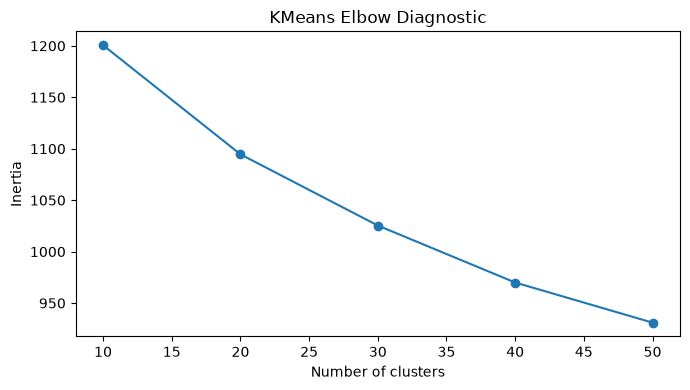

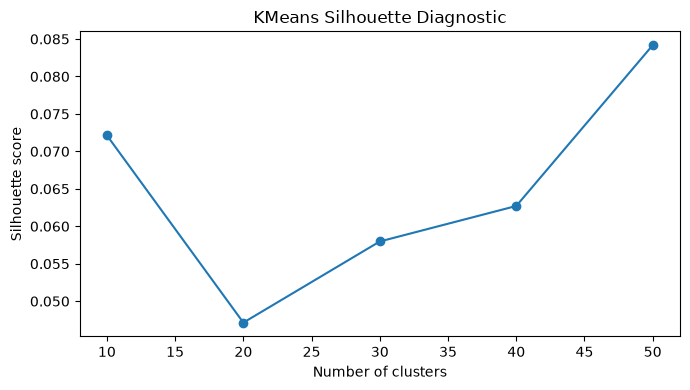

In [7]:
# Cell 15 — Visualize cluster diagnostics

plt.figure(figsize=(7, 4))
plt.plot(
    cluster_diagnostics["k"],
    cluster_diagnostics["inertia"],
    marker="o"
)
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("KMeans Elbow Diagnostic")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(
    cluster_diagnostics["k"],
    cluster_diagnostics["silhouette_score"],
    marker="o"
)
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette score")
plt.title("KMeans Silhouette Diagnostic")
plt.tight_layout()
plt.show()


### Cluster-selection decision

Among the tested values, `k = 50` produced the highest observed silhouette score (approximately **0.084**).

The scores are low overall, confirming that the vocabulary contains overlapping semantic domains rather than sharply separated groups.

Because clustering is exploratory rather than the final classification method, `k = 50` is retained as a practical descriptive solution.


In [8]:
# Cell 17 — Fit the exploratory KMeans model

SELECTED_K = 50

kmeans = KMeans(
    n_clusters=SELECTED_K,
    random_state=42,
    n_init=10
)

cluster_vocabulary[
    "cluster"
] = kmeans.fit_predict(
    cluster_embeddings
)

display(
    cluster_vocabulary.head()
)


,skill,job_frequency,cluster
6217,Omsorg,1471,37
4801,Kundeservice,1396,25
3267,Helse,1106,41
1269,Butikk,1057,0
7597,Salg,981,0


## 6. Inspect the semantic clusters

The ten most frequent skills in each cluster are displayed to understand the broad semantic structure.

The cluster labels are **not** used as final digital or AI classifications.


In [9]:
# Cell 19 — Display representative skills from each cluster

cluster_summary = (
    cluster_vocabulary
    .sort_values(
        ["cluster", "job_frequency"],
        ascending=[True, False]
    )
    .groupby("cluster")
    .head(10)
)

for cluster_id in sorted(
    cluster_summary["cluster"].unique()
):
    skills = (
        cluster_summary.loc[
            cluster_summary["cluster"]
            == cluster_id,
            "skill"
        ]
        .tolist()
    )

    print(f"CLUSTER {cluster_id}")
    print(", ".join(skills))
    print()


CLUSTER 0
Butikk, Salg, Butikkmedarbeider, Kundebehandling, Butikkselger, Innkjøp, Butikkleder, Detaljhandel, Butikksjef, Markedsføring

CLUSTER 1
Barnehage, Matlaging, Akuttmedisin, Rydding, Primærkontakt, Allmennmedisin, Tekstil, Håndverk, Optikk, Hårklipp

CLUSTER 2
Strategi, Installasjon, Python, Systemutvikling, Programmering, Prosessforbedring, Systemutvikler, Programmerer, Teknisk forståelse, Teknisk support

CLUSTER 3
Dokumentasjon, Rapportering, Arkiv, Sosiale medier, Journalføring, Fakturering, Bibliotek, Journalsystem, Dokumentforvaltning, Video

CLUSTER 4
Hjemmetjeneste, Bolig, Husarbeid, Hjemmehjelp, Eiendom, Eiendomsforvaltning, Hjemmebasert omsorg, hjemmetjeneste, Hjemmekontor, Møbler

CLUSTER 5
Rådgiver, Pasientbehandling, Saksbehandling, Sykehjem, Rådgivning, Praktisk bistand, Ekstrahjelp, Behandling, Gjestebehandling, omsorg

CLUSTER 6
Ingeniør, Teknologi, Håndverker, Teknisk drift, Teknisk dokumentasjon, Tekniker, Prosjektingeniør, Teknisk arbeid, Teknisk tegning, Se

### What clustering contributes — and why it is not the final classifier

The clusters reveal recognizable areas such as data, software, healthcare, engineering, administration, and digitalization.

However, several clusters also mix relevant and unrelated concepts. This is expected because KMeans must assign **every skill** to a cluster; it has no option to say that a skill does not belong to a target domain.

**Decision:** clustering remains exploratory evidence only.

The final digital classification is anchored to ESCO so that mixed clusters are not treated as clean future-skill categories.


# Part B — Digital-skill classification with ESCO

## 7. Why use ESCO?

For the final digital classification, we need an external reference that is:

- designed for labor-market analysis
- multilingual
- based on standardized skill concepts
- able to identify digital concepts without a manually maintained keyword list

ESCO provides multilingual skill concepts identified by stable concept URIs, together with an official `digitalSkillsCollection`.

### Important classification principle

Observed NAV skills are mapped against **all ESCO skill concepts first**.

Only after a NAV skill is mapped do we ask whether the selected ESCO concept is officially digital.

This avoids forcing every observed skill into the digital domain.

Official ESCO resources used in this project:

- `https://esco.ec.europa.eu/en/use-esco/download`
- `https://esco.ec.europa.eu/en/structure-esco-downloadable-datasets`
- `https://esco.ec.europa.eu/en/about-esco/escopedia/escopedia/digital-skills-labelling-esco`


## 8. Locate the downloaded ESCO files

The project uses Norwegian and English ESCO CSV packages extracted under:

`data/external/esco/`

The helper below searches all subfolders so the downloaded version folder can remain unchanged.


In [10]:
# Cell 23 — Locate the required ESCO files

from pathlib import Path

ESCO_ROOT = Path(
    "../data/external/esco"
).resolve()


def find_esco_file(filename):
    matches = list(
        ESCO_ROOT.rglob(filename)
    )

    if not matches:
        raise FileNotFoundError(
            f"Could not find {filename} "
            f"under {ESCO_ROOT}"
        )

    if len(matches) > 1:
        print(
            f"Warning: multiple files found "
            f"for {filename}. Using the first."
        )

    return matches[0]


skills_no_path = find_esco_file(
    "skills_no.csv"
)

skills_en_path = find_esco_file(
    "skills_en.csv"
)

digital_no_path = find_esco_file(
    "digitalSkillsCollection_no.csv"
)

digital_en_path = find_esco_file(
    "digitalSkillsCollection_en.csv"
)

print("Norwegian skills:", skills_no_path)
print("English skills:", skills_en_path)
print(
    "Norwegian digital collection:",
    digital_no_path
)
print(
    "English digital collection:",
    digital_en_path
)


Norwegian skills: E:\@UIO\Python\Norway-future-skills\data\external\esco\norwegian\v1.2.1\skills_no.csv
English skills: E:\@UIO\Python\Norway-future-skills\data\external\esco\english\v1.2.1\skills_en.csv
Norwegian digital collection: E:\@UIO\Python\Norway-future-skills\data\external\esco\norwegian\v1.2.1\digitalSkillsCollection_no.csv
English digital collection: E:\@UIO\Python\Norway-future-skills\data\external\esco\english\v1.2.1\digitalSkillsCollection_en.csv


## 9. Load ESCO skills and the official digital collection

The locally downloaded ESCO release is treated as the operational reference for this analysis.

The number of digital concepts is calculated directly from the downloaded files rather than assumed from documentation.


In [11]:
# Cell 25 — Load ESCO CSV files

def read_esco_csv(path):
    try:
        return pd.read_csv(
            path,
            encoding="utf-8-sig"
        )
    except Exception:
        return pd.read_csv(
            path,
            encoding="utf-8-sig",
            sep=None,
            engine="python"
        )


esco_skills_no = read_esco_csv(
    skills_no_path
)

esco_skills_en = read_esco_csv(
    skills_en_path
)

esco_digital_no = read_esco_csv(
    digital_no_path
)

esco_digital_en = read_esco_csv(
    digital_en_path
)

print(
    "Norwegian skills:",
    esco_skills_no.shape
)

print(
    "English skills:",
    esco_skills_en.shape
)

print(
    "Norwegian digital collection:",
    esco_digital_no.shape
)

print(
    "English digital collection:",
    esco_digital_en.shape
)


Norwegian skills: (13960, 13)
English skills: (13960, 13)
Norwegian digital collection: (1284, 10)
English digital collection: (1284, 10)


In [12]:
# Cell 26 — Build the official ESCO digital concept set

def detect_column(
    df,
    candidates,
    required=True
):
    lookup = {
        str(column).strip().lower():
        column
        for column in df.columns
    }

    for candidate in candidates:
        key = candidate.lower()

        if key in lookup:
            return lookup[key]

    if required:
        raise KeyError(
            f"None of {candidates} found. "
            f"Available columns: "
            f"{list(df.columns)}"
        )

    return None


def get_uri_set(collection_df):
    uri_col = detect_column(
        collection_df,
        ["conceptUri", "conceptURI", "uri"]
    )

    return set(
        collection_df[uri_col]
        .dropna()
        .astype(str)
    )


digital_uris = (
    get_uri_set(esco_digital_no)
    | get_uri_set(esco_digital_en)
)

print(
    "ESCO skill concepts:",
    esco_skills_en[
        "conceptUri"
    ].nunique()
)

print(
    "ESCO concepts labelled digital:",
    len(digital_uris)
)

print(
    "\nAvailable ESCO skill columns:"
)

print(
    esco_skills_en.columns.tolist()
)


ESCO skill concepts: 13939
ESCO concepts labelled digital: 1284

Available ESCO skill columns:
['conceptType', 'conceptUri', 'skillType', 'reuseLevel', 'preferredLabel', 'altLabels', 'hiddenLabels', 'status', 'modifiedDate', 'scopeNote', 'definition', 'inScheme', 'description']


### ESCO data check

In the ESCO v1.2.1 files used during this project, the skills table contained **13,960 skill concepts** and the official digital collection contained **1,284 unique digital concepts**.

The classification itself is based on concept URIs, not on a manually written digital keyword list.


## 10. Match observed NAV skills to ESCO concepts

The matching process has three stages:

1. **Exact matching**  
   Compare NAV skills with Norwegian and English ESCO preferred and alternative labels. An exact match is accepted only when the normalized label maps unambiguously to one ESCO concept.

2. **Candidate retrieval for unmatched skills**  
   Enrich the NAV skill with representative job titles and categories, then use multilingual embeddings to retrieve a small set of plausible ESCO concepts.

3. **Context-aware reranking**  
   Compare the NAV skill context jointly with richer ESCO concept descriptions using a CrossEncoder.

This retrieve-and-rerank approach replaces a weaker short-string method that produced false semantic matches.

Reference: `https://www.sbert.net/examples/sentence_transformer/applications/retrieve_rerank/README.html`


### 10.1 Build an ESCO label reference

Preferred and alternative labels are normalized for exact matching while preserving the original labels for reporting.


In [13]:
# Cell 30 — Build searchable ESCO labels

import re
import ast
import unicodedata


def normalize_label(text):
    if pd.isna(text):
        return ""

    text = unicodedata.normalize(
        "NFKC",
        str(text)
    )

    text = text.casefold().strip()

    text = re.sub(
        r"\s+",
        " ",
        text
    )

    return text


def split_alt_labels(value):
    if pd.isna(value):
        return []

    if isinstance(
        value,
        (list, tuple, set)
    ):
        return [
            str(item).strip()
            for item in value
            if str(item).strip()
        ]

    text = str(value).strip()

    if not text:
        return []

    try:
        parsed = ast.literal_eval(text)

        if isinstance(
            parsed,
            (list, tuple, set)
        ):
            return [
                str(item).strip()
                for item in parsed
                if str(item).strip()
            ]

    except (ValueError, SyntaxError):
        pass

    text = text.replace(
        "\\n",
        "\n"
    )

    parts = re.split(
        r"\s*(?:\r?\n|;|\|)\s*",
        text
    )

    return [
        part.strip()
        for part in parts
        if part.strip()
    ]


def build_esco_label_reference(
    skills_df,
    language
):
    records = []

    for _, row in skills_df.iterrows():
        uri = str(
            row["conceptUri"]
        )

        preferred = row[
            "preferredLabel"
        ]

        if pd.notna(preferred):
            records.append({
                "esco_uri": uri,
                "esco_match_label":
                    str(preferred).strip(),
                "label_type": "preferred",
                "language": language
            })

        for alt_label in split_alt_labels(
            row["altLabels"]
        ):
            records.append({
                "esco_uri": uri,
                "esco_match_label":
                    alt_label,
                "label_type": "alternative",
                "language": language
            })

    return pd.DataFrame(records)


esco_label_reference = pd.concat(
    [
        build_esco_label_reference(
            esco_skills_no,
            "no"
        ),
        build_esco_label_reference(
            esco_skills_en,
            "en"
        )
    ],
    ignore_index=True
)

esco_label_reference[
    "label_normalized"
] = (
    esco_label_reference[
        "esco_match_label"
    ]
    .apply(normalize_label)
)

esco_label_reference[
    "is_digital_esco"
] = (
    esco_label_reference[
        "esco_uri"
    ]
    .astype(str)
    .isin(digital_uris)
)

esco_label_reference = (
    esco_label_reference
    .drop_duplicates(
        subset=[
            "esco_uri",
            "label_normalized",
            "language"
        ]
    )
    .reset_index(drop=True)
)

print(
    "Searchable ESCO labels:",
    f"{len(esco_label_reference):,}"
)

print(
    "Unique ESCO concepts:",
    esco_label_reference[
        "esco_uri"
    ].nunique()
)

print(
    "Digital ESCO concepts:",
    esco_label_reference.loc[
        esco_label_reference[
            "is_digital_esco"
        ],
        "esco_uri"
    ].nunique()
)


Searchable ESCO labels: 119,180
Unique ESCO concepts: 13939
Digital ESCO concepts: 1284


### 10.2 Exact matching

Exact matches are accepted only when the same normalized NAV label points to **one unique ESCO URI**.

If an exact word maps to several concepts, it remains ambiguous and is passed to the context-aware stage.


In [14]:
# Cell 32 — Match unambiguous exact labels

nav_skill_reference = (
    skills_jobs_df
    .groupby("skill")
    .agg(
        job_frequency=(
            "job_id",
            "nunique"
        )
    )
    .reset_index()
)

nav_skill_reference[
    "skill_normalized"
] = (
    nav_skill_reference[
        "skill"
    ]
    .apply(normalize_label)
)

exact_candidates = (
    nav_skill_reference
    .merge(
        esco_label_reference,
        left_on="skill_normalized",
        right_on="label_normalized",
        how="inner"
    )
)

exact_uri_counts = (
    exact_candidates
    .groupby("skill")[
        "esco_uri"
    ]
    .nunique()
)

unambiguous_exact_skills = set(
    exact_uri_counts[
        exact_uri_counts == 1
    ].index
)

ambiguous_exact_skills = set(
    exact_uri_counts[
        exact_uri_counts > 1
    ].index
)

exact_matches = (
    exact_candidates[
        exact_candidates[
            "skill"
        ].isin(
            unambiguous_exact_skills
        )
    ]
    .assign(
        label_priority=lambda frame:
        frame["label_type"].map({
            "preferred": 0,
            "alternative": 1
        })
    )
    .sort_values(
        ["skill", "label_priority"]
    )
    .drop_duplicates(
        subset="skill"
    )
)

exact_matches = (
    exact_matches[
        [
            "skill",
            "job_frequency",
            "esco_uri",
            "esco_match_label",
            "language",
            "is_digital_esco"
        ]
    ]
    .rename(
        columns={
            "esco_match_label":
                "esco_label",
            "language":
                "esco_language"
        }
    )
    .copy()
)

exact_matches[
    "match_method"
] = "exact"

exact_matches[
    "retrieval_score"
] = np.nan

exact_matches[
    "rerank_score"
] = 1.0

exact_matches[
    "rerank_margin"
] = np.nan

print(
    "NAV skills:",
    len(nav_skill_reference)
)

print(
    "Unambiguous exact matches:",
    len(exact_matches)
)

print(
    "Ambiguous exact labels:",
    len(ambiguous_exact_skills)
)

print(
    "Remaining for context-aware matching:",
    len(nav_skill_reference)
    - len(exact_matches)
)


NAV skills: 10997
Unambiguous exact matches: 456
Ambiguous exact labels: 12
Remaining for context-aware matching: 10541


### 10.3 Build job-market context for unmatched skills

Short labels can be ambiguous. For example, the meaning of a word such as `Sikkerhet` depends strongly on the jobs in which it appears.

Each skill is therefore enriched with representative:

- job titles
- job categories

The unreliable source `occupation` field is deliberately excluded.


In [15]:
# Cell 34 — Build NAV skill-context documents

def representative_values(
    series,
    n=5,
    max_chars=140
):
    values = (
        series
        .dropna()
        .astype(str)
        .str.strip()
    )

    values = values[
        ~values
        .str.lower()
        .eq("not classified")
    ]

    top_values = (
        values
        .value_counts()
        .head(n)
        .index
        .tolist()
    )

    return [
        value[:max_chars]
        for value in top_values
    ]


skill_context = (
    skills_jobs_df
    .groupby("skill")
    .agg(
        example_titles=(
            "title",
            lambda series:
            representative_values(
                series,
                n=3,
                max_chars=140
            )
        ),
        example_categories=(
            "category",
            lambda series:
            representative_values(
                series,
                n=5,
                max_chars=140
            )
        )
    )
    .reset_index()
)


def build_nav_context(row):
    titles = " | ".join(
        row["example_titles"]
    )

    categories = " | ".join(
        row["example_categories"]
    )

    parts = [
        f"Skill: {row['skill']}"
    ]

    if titles:
        parts.append(
            f"Common job titles: {titles}"
        )

    if categories:
        parts.append(
            f"Common job categories: "
            f"{categories}"
        )

    return ". ".join(parts)


skill_context[
    "nav_context"
] = (
    skill_context.apply(
        build_nav_context,
        axis=1
    )
)

display(
    skill_context.head()
)


,skill,example_titles,example_categories,nav_context
0,.NET,[Senior utvikler -- påvirk arkitektur og tekno...,"[Systemutvikler, Systemutvikler, Systemanalyti...",Skill: .NET. Common job titles: Senior utvikle...
1,.Net,[Vi søker erfaren .Net fullstackutvikler],"[.Net Utvikler, .Net Utvikler, Applikasjonspro...",Skill: .Net. Common job titles: Vi søker erfar...
2,.net,[Ønsker du å bli en del av et av Norges størst...,"[Full-stack-utvikler, Full-stack-utvikler, Pro...",Skill: .net. Common job titles: Ønsker du å bl...
3,110-sentral,[Samfunnsvitar til arbeidet med nytt naudnett ...,"[Andre ingeniører, Sikkerhetsrådgiver (helse, ...",Skill: 110-sentral. Common job titles: Samfunn...
4,12V,"[Har du mekanisk sans, båtinteresse og kontrol...","[Anleggsmaskin- og industrimekanikere, Bilmeka...",Skill: 12V. Common job titles: Har du mekanisk...


### 10.4 Build richer ESCO concept documents

Each ESCO concept is represented by the available:

- Norwegian and English preferred labels
- alternative labels
- descriptions
- definitions

This reduces dependence on superficial similarity between short strings.


In [16]:
# Cell 36 — Build one semantic document per ESCO concept

def compact_alt_labels(
    value,
    limit=8
):
    labels = split_alt_labels(
        value
    )

    return "; ".join(
        labels[:limit]
    )


def clean_optional_text(
    value,
    max_chars=500
):
    if pd.isna(value):
        return ""

    text = re.sub(
        r"\s+",
        " ",
        str(value).strip()
    )

    return text[:max_chars]


def prepare_esco_concepts(
    skills_df,
    language
):
    columns = [
        "conceptUri",
        "preferredLabel",
        "altLabels",
        "description",
        "definition"
    ]

    result = skills_df[
        columns
    ].copy()

    result = result.rename(
        columns={
            "conceptUri":
                "esco_uri",
            "preferredLabel":
                f"preferred_{language}",
            "altLabels":
                f"alt_{language}",
            "description":
                f"description_{language}",
            "definition":
                f"definition_{language}"
        }
    )

    result[
        "esco_uri"
    ] = result[
        "esco_uri"
    ].astype(str)

    return result.drop_duplicates(
        subset="esco_uri"
    )


esco_concepts_no = (
    prepare_esco_concepts(
        esco_skills_no,
        "no"
    )
)

esco_concepts_en = (
    prepare_esco_concepts(
        esco_skills_en,
        "en"
    )
)

esco_concepts = (
    esco_concepts_no
    .merge(
        esco_concepts_en,
        on="esco_uri",
        how="outer"
    )
)

esco_concepts[
    "is_digital_esco"
] = (
    esco_concepts[
        "esco_uri"
    ]
    .isin(digital_uris)
)


def build_esco_document(row):
    parts = []

    preferred_no = clean_optional_text(
        row.get("preferred_no"),
        220
    )

    preferred_en = clean_optional_text(
        row.get("preferred_en"),
        220
    )

    if preferred_no:
        parts.append(
            f"Norwegian skill: "
            f"{preferred_no}"
        )

    if preferred_en:
        parts.append(
            f"English skill: "
            f"{preferred_en}"
        )

    alt_no = compact_alt_labels(
        row.get("alt_no"),
        limit=8
    )

    alt_en = compact_alt_labels(
        row.get("alt_en"),
        limit=8
    )

    if alt_no:
        parts.append(
            "Norwegian alternative "
            f"labels: {alt_no}"
        )

    if alt_en:
        parts.append(
            "English alternative "
            f"labels: {alt_en}"
        )

    description_no = (
        clean_optional_text(
            row.get(
                "description_no"
            ),
            500
        )
    )

    description_en = (
        clean_optional_text(
            row.get(
                "description_en"
            ),
            500
        )
    )

    definition_no = (
        clean_optional_text(
            row.get(
                "definition_no"
            ),
            350
        )
    )

    definition_en = (
        clean_optional_text(
            row.get(
                "definition_en"
            ),
            350
        )
    )

    if description_no:
        parts.append(
            "Norwegian description: "
            f"{description_no}"
        )

    if description_en:
        parts.append(
            "English description: "
            f"{description_en}"
        )

    if definition_no:
        parts.append(
            "Norwegian definition: "
            f"{definition_no}"
        )

    if definition_en:
        parts.append(
            "English definition: "
            f"{definition_en}"
        )

    return ". ".join(parts)


esco_concepts[
    "esco_document"
] = (
    esco_concepts.apply(
        build_esco_document,
        axis=1
    )
)

print(
    "ESCO concept documents:",
    esco_concepts[
        "esco_uri"
    ].nunique()
)


ESCO concept documents: 13939


### 10.5 Retrieve candidate ESCO concepts

Only skills without an unambiguous exact match enter this stage.

A multilingual bi-encoder retrieves the top **20 candidate ESCO concepts** for each unmatched NAV skill. Retrieval is intentionally broad; it is not the final classification decision.


In [17]:
# Cell 38 — Retrieve semantic ESCO candidates

from sentence_transformers import util

exact_matched_skills = set(
    exact_matches["skill"]
)

semantic_nav_skills = (
    nav_skill_reference[
        ~nav_skill_reference[
            "skill"
        ].isin(
            exact_matched_skills
        )
    ]
    .merge(
        skill_context[
            ["skill", "nav_context"]
        ],
        on="skill",
        how="left"
    )
    .reset_index(drop=True)
)

print(
    "Skills requiring "
    "context-aware matching:",
    len(semantic_nav_skills)
)

TOP_K = 20

nav_context_embeddings = (
    embedding_model.encode(
        semantic_nav_skills[
            "nav_context"
        ].tolist(),
        show_progress_bar=True,
        normalize_embeddings=True
    )
)

esco_concept_embeddings = (
    embedding_model.encode(
        esco_concepts[
            "esco_document"
        ].tolist(),
        show_progress_bar=True,
        normalize_embeddings=True
    )
)

retrieval_hits = (
    util.semantic_search(
        nav_context_embeddings,
        esco_concept_embeddings,
        top_k=TOP_K
    )
)

print(
    f"Retrieved up to {TOP_K} "
    "ESCO candidates for each "
    "unmatched NAV skill."
)


Skills requiring context-aware matching: 10541


Batches:   0%|          | 0/330 [00:00<?, ?it/s]

Batches:   0%|          | 0/436 [00:00<?, ?it/s]

Retrieved up to 20 ESCO candidates for each unmatched NAV skill.


### 10.6 Rerank only plausible digital cases

CrossEncoders are more precise than bi-encoders but substantially slower.

To keep the workflow practical, the reranker is used only when a digital ESCO concept appears among the retrieved candidates.

For such skills, the model compares at most:

- the strongest retrieved digital concept
- the strongest retrieved non-digital concept

Skills with no digital concept among their top retrieval candidates are provisionally screened as non-digital.

Model: `cross-encoder/mmarco-mMiniLMv2-L12-H384-v1`

> **Runtime note:** this is the most computationally expensive cell. GPU execution is substantially faster than CPU execution.


In [18]:
# Cell 40 — Build a small shortlist and run the CrossEncoder

from sentence_transformers import CrossEncoder
import torch

DEVICE = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(
    "Reranker device:",
    DEVICE
)

reranker = CrossEncoder(
    "cross-encoder/"
    "mmarco-mMiniLMv2-L12-H384-v1",
    device=DEVICE,
    max_length=256,
    activation_fn=torch.nn.Sigmoid()
)

candidate_records = []
rerank_pairs = []
rerank_row_indices = []

screened_non_digital = 0
skills_sent_to_reranker = 0

for nav_index, hits in enumerate(
    retrieval_hits
):
    nav_row = (
        semantic_nav_skills
        .iloc[nav_index]
    )

    query_text = (
        nav_row["nav_context"]
    )

    candidates = []

    for hit in hits:
        corpus_id = hit[
            "corpus_id"
        ]

        esco_row = (
            esco_concepts
            .iloc[corpus_id]
        )

        candidates.append({
            "nav_index":
                nav_index,
            "skill":
                nav_row["skill"],
            "job_frequency":
                nav_row[
                    "job_frequency"
                ],
            "esco_index":
                corpus_id,
            "esco_uri":
                esco_row["esco_uri"],
            "esco_label_no":
                esco_row[
                    "preferred_no"
                ],
            "esco_label_en":
                esco_row[
                    "preferred_en"
                ],
            "is_digital_esco":
                bool(
                    esco_row[
                        "is_digital_esco"
                    ]
                ),
            "retrieval_score":
                float(hit["score"]),
            "esco_document":
                esco_row[
                    "esco_document"
                ]
        })

    digital_candidates = [
        candidate
        for candidate in candidates
        if candidate[
            "is_digital_esco"
        ]
    ]

    non_digital_candidates = [
        candidate
        for candidate in candidates
        if not candidate[
            "is_digital_esco"
        ]
    ]

    if not digital_candidates:
        best_candidate = (
            candidates[0].copy()
        )

        best_candidate[
            "was_reranked"
        ] = False

        candidate_records.append(
            best_candidate
        )

        screened_non_digital += 1
        continue

    shortlist = [
        digital_candidates[0]
    ]

    if non_digital_candidates:
        shortlist.append(
            non_digital_candidates[0]
        )

    skills_sent_to_reranker += 1

    for candidate in shortlist:
        candidate = candidate.copy()

        candidate[
            "was_reranked"
        ] = True

        row_index = len(
            candidate_records
        )

        candidate_records.append(
            candidate
        )

        rerank_row_indices.append(
            row_index
        )

        rerank_pairs.append(
            (
                query_text,
                candidate[
                    "esco_document"
                ]
            )
        )

candidate_matches = pd.DataFrame(
    candidate_records
)

candidate_matches[
    "rerank_score"
] = np.nan

print(
    "Total unmatched NAV skills:",
    len(semantic_nav_skills)
)

print(
    "Screened as non-digital "
    "without reranking:",
    screened_non_digital
)

print(
    "Skills sent to CrossEncoder:",
    skills_sent_to_reranker
)

print(
    "Candidate pairs to rerank:",
    len(rerank_pairs)
)

if rerank_pairs:
    batch_size = (
        128
        if DEVICE == "cuda"
        else 32
    )

    rerank_scores = (
        reranker.predict(
            rerank_pairs,
            batch_size=batch_size,
            show_progress_bar=True
        )
    )

    rerank_scores = (
        np.asarray(
            rerank_scores
        )
        .reshape(-1)
    )

    candidate_matches.loc[
        rerank_row_indices,
        "rerank_score"
    ] = rerank_scores

candidate_matches = (
    candidate_matches
    .drop(
        columns="esco_document",
        errors="ignore"
    )
)

display(
    candidate_matches.head()
)


Reranker device: cpu


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Total unmatched NAV skills: 10541
Screened as non-digital without reranking: 4278
Skills sent to CrossEncoder: 6263
Candidate pairs to rerank: 12485


Batches:   0%|          | 0/391 [00:00<?, ?it/s]

,nav_index,skill,job_frequency,esco_index,esco_uri,esco_label_no,esco_label_en,is_digital_esco,retrieval_score,was_reranked,rerank_score
0,0,110-sentral,2,3422,http://data.europa.eu/esco/skill/3e61ee41-2bd9...,lede selskapsavdelingsledere,lead managers of company departments,False,0.608227,False,NaN
1,1,12V,1,2591,http://data.europa.eu/esco/skill/2ee670aa-c687...,fartøymekanikk,mechanics of vessels,False,0.586779,False,NaN
2,2,2. linje brukerstøtte,1,10346,http://data.europa.eu/esco/skill/bec4359e-cb92...,Metoder innen IKT-prosjektledelse,ICT project management methodologies,True,0.551693,True,0.003107
3,2,2. linje brukerstøtte,1,3422,http://data.europa.eu/esco/skill/3e61ee41-2bd9...,lede selskapsavdelingsledere,lead managers of company departments,False,0.532610,True,0.008224
4,3,2. linje support,1,11,http://data.europa.eu/esco/skill/00298d97-3dc3...,lede politietterforskning,lead police investigations,False,0.560212,False,NaN


### 10.7 Require retrieval and reranker agreement

A semantic skill becomes a **digital-consensus candidate** only when both stages prefer the digital ESCO concept:

- retrieval score for digital > retrieval score for non-digital
- reranker score for digital > reranker score for non-digital

If the models disagree, the skill is classified conservatively as non-digital.


In [19]:
# Cell 42 — Compare digital and non-digital candidates

screened_matches = (
    candidate_matches[
        ~candidate_matches[
            "was_reranked"
        ]
    ]
    .copy()
)

screened_matches[
    "esco_label"
] = (
    screened_matches[
        "esco_label_no"
    ]
    .fillna(
        screened_matches[
            "esco_label_en"
        ]
    )
)

screened_matches[
    "esco_language"
] = np.where(
    screened_matches[
        "esco_label_no"
    ].notna(),
    "no",
    "en"
)

screened_matches[
    "rerank_margin"
] = np.nan

screened_matches[
    "match_method"
] = (
    "retrieval_screen_non_digital"
)

reranked = (
    candidate_matches[
        candidate_matches[
            "was_reranked"
        ]
    ]
    .copy()
)

digital_candidate = (
    reranked[
        reranked[
            "is_digital_esco"
        ]
    ]
    .sort_values(
        [
            "nav_index",
            "rerank_score"
        ],
        ascending=[
            True,
            False
        ]
    )
    .drop_duplicates(
        "nav_index"
    )
)

non_digital_candidate = (
    reranked[
        ~reranked[
            "is_digital_esco"
        ]
    ]
    .sort_values(
        [
            "nav_index",
            "rerank_score"
        ],
        ascending=[
            True,
            False
        ]
    )
    .drop_duplicates(
        "nav_index"
    )
)

comparison = (
    digital_candidate
    .merge(
        non_digital_candidate,
        on="nav_index",
        suffixes=(
            "_digital",
            "_non_digital"
        ),
        how="inner"
    )
)

comparison[
    "retrieval_margin"
] = (
    comparison[
        "retrieval_score_digital"
    ]
    -
    comparison[
        "retrieval_score_non_digital"
    ]
)

comparison[
    "rerank_margin"
] = (
    comparison[
        "rerank_score_digital"
    ]
    -
    comparison[
        "rerank_score_non_digital"
    ]
)

comparison[
    "digital_consensus"
] = (
    (
        comparison[
            "retrieval_margin"
        ] > 0
    )
    &
    (
        comparison[
            "rerank_margin"
        ] > 0
    )
)

display(
    comparison[
        [
            "skill_digital",
            "esco_label_no_digital",
            "esco_label_no_non_digital",
            "retrieval_margin",
            "rerank_margin",
            "digital_consensus"
        ]
    ]
    .head(20)
)


,skill_digital,esco_label_no_digital,esco_label_no_non_digital,retrieval_margin,rerank_margin,digital_consensus
0,2. linje brukerstøtte,Metoder innen IKT-prosjektledelse,lede selskapsavdelingsledere,0.019083,-0.005117,False
1,24SevenOffice,online jobbplattformer,posisjonere kjernearbeidsstykker,-0.066376,-0.005510,False
2,3. linje support,tjenesteorientert modellering,konstruere arbeidsplattform,0.000380,-0.001331,False
3,3D konstruksjon,design for maskinvaredeler og forbindelser,skinnekonstruksjonsteknikk,-0.011522,0.156775,False
4,3D modellering,3D-modellering,tolke 3D-planer,0.075043,0.271834,True
5,3D-design,utforme elektriske systemer,skinnekonstruksjonsteknikk,-0.024804,0.014541,False
6,3D-modellering,lage 3D CAD-fottøyprototyper,luftfartsteknologi,-0.020068,0.445889,False
7,3D-scanning,3D-modellering,strømlinjeformet produksjon,0.017511,0.950884,True
8,5S,dataprogrammering,5S-metodikk,0.006864,-0.993529,False
9,A-lis,dataprogrammering,kombinere flere kunnskapsfelt,-0.045131,-0.000374,False


In [20]:
# Cell 43 — Build the context-aware match table

semantic_records = []

for _, row in comparison.iterrows():

    if row[
        "digital_consensus"
    ]:
        semantic_records.append({
            "skill":
                row["skill_digital"],
            "job_frequency":
                row[
                    "job_frequency_digital"
                ],
            "esco_uri":
                row[
                    "esco_uri_digital"
                ],
            "esco_label":
                (
                    row[
                        "esco_label_no_digital"
                    ]
                    if pd.notna(
                        row[
                            "esco_label_no_digital"
                        ]
                    )
                    else row[
                        "esco_label_en_digital"
                    ]
                ),
            "esco_language":
                (
                    "no"
                    if pd.notna(
                        row[
                            "esco_label_no_digital"
                        ]
                    )
                    else "en"
                ),
            "is_digital_esco":
                True,
            "retrieval_score":
                row[
                    "retrieval_score_digital"
                ],
            "rerank_score":
                row[
                    "rerank_score_digital"
                ],
            "rerank_margin":
                row[
                    "rerank_margin"
                ],
            "match_method":
                "digital_consensus"
        })

    else:
        semantic_records.append({
            "skill":
                row[
                    "skill_non_digital"
                ],
            "job_frequency":
                row[
                    "job_frequency_non_digital"
                ],
            "esco_uri":
                row[
                    "esco_uri_non_digital"
                ],
            "esco_label":
                (
                    row[
                        "esco_label_no_non_digital"
                    ]
                    if pd.notna(
                        row[
                            "esco_label_no_non_digital"
                        ]
                    )
                    else row[
                        "esco_label_en_non_digital"
                    ]
                ),
            "esco_language":
                (
                    "no"
                    if pd.notna(
                        row[
                            "esco_label_no_non_digital"
                        ]
                    )
                    else "en"
                ),
            "is_digital_esco":
                False,
            "retrieval_score":
                row[
                    "retrieval_score_non_digital"
                ],
            "rerank_score":
                row[
                    "rerank_score_non_digital"
                ],
            "rerank_margin":
                row[
                    "rerank_margin"
                ],
            "match_method":
                "non_digital_disagreement"
        })

semantic_compared = pd.DataFrame(
    semantic_records
)

screened_result = (
    screened_matches[
        [
            "skill",
            "job_frequency",
            "esco_uri",
            "esco_label",
            "esco_language",
            "is_digital_esco",
            "retrieval_score",
            "rerank_score",
            "rerank_margin",
            "match_method"
        ]
    ]
)

semantic_matches = pd.concat(
    [
        semantic_compared,
        screened_result
    ],
    ignore_index=True
)

print(
    semantic_matches[
        "match_method"
    ].value_counts()
)


match_method
non_digital_disagreement        5704
retrieval_screen_non_digital    4278
digital_consensus                518
Name: count, dtype: int64


### 10.8 Combine exact and context-aware matches

Every observed NAV skill now belongs to one of the following paths:

- exact ESCO match
- digital consensus
- non-digital disagreement
- retrieval-screened non-digital


In [21]:
# Cell 45 — Combine all ESCO mapping results

match_columns = [
    "skill",
    "job_frequency",
    "esco_uri",
    "esco_label",
    "esco_language",
    "is_digital_esco",
    "retrieval_score",
    "rerank_score",
    "rerank_margin",
    "match_method"
]

esco_matches = pd.concat(
    [
        exact_matches[
            match_columns
        ],
        semantic_matches[
            match_columns
        ]
    ],
    ignore_index=True
)

print(
    "Total NAV skills:",
    nav_skill_reference[
        "skill"
    ].nunique()
)

print(
    "Total mapped skills:",
    esco_matches[
        "skill"
    ].nunique()
)

print("\nMatch methods:")

print(
    esco_matches[
        "match_method"
    ].value_counts()
)

print(
    "\nCurrently mapped to "
    "digital ESCO concepts:",
    esco_matches.loc[
        esco_matches[
            "is_digital_esco"
        ],
        "skill"
    ].nunique()
)


Total NAV skills: 10997
Total mapped skills: 10956

Match methods:
match_method
non_digital_disagreement        5704
retrieval_screen_non_digital    4278
digital_consensus                518
exact                            456
Name: count, dtype: int64

Currently mapped to digital ESCO concepts: 636


### 10.9 Smoke-test previously problematic terms

Earlier short-string matching produced implausible mappings for several ambiguous words.

The following table is a **diagnostic check**, not a manual filtering rule. It verifies that the improved context-aware method handles those known failure cases more sensibly.


In [22]:
# Cell 47 — Inspect known ambiguous examples

problem_skills = [
    "Omsorg",
    "Salg",
    "Leder",
    "Sikkerhet",
    "Servering",
    "BPA",
    "Teknologi",
    "Politi"
]

display(
    esco_matches[
        esco_matches[
            "skill"
        ].isin(
            problem_skills
        )
    ][
        [
            "skill",
            "job_frequency",
            "esco_label",
            "match_method",
            "is_digital_esco",
            "retrieval_score",
            "rerank_score",
            "rerank_margin"
        ]
    ]
    .sort_values("skill")
)


,skill,job_frequency,esco_label,match_method,is_digital_esco,retrieval_score,rerank_score,rerank_margin
6894,BPA,246,personalledelse,retrieval_screen_non_digital,False,0.505071,NaN,NaN
8636,Leder,895,lede selskapsavdelingsledere,retrieval_screen_non_digital,False,0.696943,NaN,NaN
9092,Omsorg,1471,prosesser ved personalressursavdelingen,retrieval_screen_non_digital,False,0.538242,NaN,NaN
9346,Politi,121,lede politietterforskning,retrieval_screen_non_digital,False,0.562338,NaN,NaN
9682,Salg,981,lede selskapsavdelingsledere,retrieval_screen_non_digital,False,0.478618,NaN,NaN
4858,Servering,262,arbeide på et matbehandlingsteam,non_digital_disagreement,False,0.593587,0.027278,-0.019451
4912,Sikkerhet,265,lede selskapsavdelingsledere,non_digital_disagreement,False,0.499950,0.344636,0.322542
5524,Teknologi,164,Metoder innen IKT-prosjektledelse,digital_consensus,True,0.562704,0.049665,0.029680


## 11. Validate digital-consensus matches

Exact matches are accepted directly because the normalized NAV label maps unambiguously to one ESCO concept.

Context-aware `digital_consensus` matches still need validation because agreement between two models does not guarantee that the selected concept is strong enough.

We inspect:

- reranker score distribution
- reranker margin
- weakest and strongest mappings
- a small stratified sample across the score range


In [23]:
# Cell 49 — Inspect digital-consensus candidates and score distributions

digital_consensus_check = (
    esco_matches[
        esco_matches[
            "match_method"
        ] == "digital_consensus"
    ]
    .copy()
)

print(
    "Digital-consensus candidates:",
    len(digital_consensus_check)
)

display(
    digital_consensus_check[
        [
            "skill",
            "job_frequency",
            "esco_label",
            "retrieval_score",
            "rerank_score",
            "rerank_margin"
        ]
    ]
    .sort_values(
        "job_frequency",
        ascending=False
    )
    .head(40)
)

print("\nRerank score distribution:")

display(
    digital_consensus_check[
        "rerank_score"
    ].describe(
        percentiles=[
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95
        ]
    )
)

print("\nRerank margin distribution:")

display(
    digital_consensus_check[
        "rerank_margin"
    ].describe(
        percentiles=[
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95
        ]
    )
)


Digital-consensus candidates: 518


,skill,job_frequency,esco_label,retrieval_score,rerank_score,rerank_margin
5524,Teknologi,164,Metoder innen IKT-prosjektledelse,0.562704,0.049665,0.029680
1572,ERP,110,transportprogramvare relatert til et ERP-system,0.552885,0.997211,0.970117
4341,Produktutvikling,79,håndtere geospatiale teknologier,0.650498,0.916909,0.013613
5453,Teknisk dokumentasjon,67,innhente trusseletterretning,0.595472,0.032917,0.023278
5368,Systemutvikling,66,dataprogrammering,0.604904,0.919450,0.198102
4363,Programmering,59,dataprogrammering,0.714441,0.918833,0.276105
475,AI,57,prinsipper for kunstig intelligens,0.558437,0.999609,0.001320
4018,Oppsøkende salg,47,søkemotoroptimalisering,0.527115,0.072195,0.005979
5367,Systemutvikler,43,dataprogrammering,0.654646,0.998863,0.002030
738,Automatiker,42,robotkomponenter,0.684346,0.983146,0.000696



Rerank score distribution:


count    518.000000
mean       0.581680
std        0.417255
min        0.000462
10%        0.009395
25%        0.077790
50%        0.796669
75%        0.990756
90%        0.999140
95%        0.999695
max        0.999975
Name: rerank_score, dtype: float64


Rerank margin distribution:


count    518.000000
mean       0.182527
std        0.278379
min        0.000002
10%        0.000749
25%        0.005008
50%        0.037300
75%        0.230006
90%        0.719103
95%        0.873347
max        0.998691
Name: rerank_margin, dtype: float64

In [24]:
# Cell 50 — Compare the weakest and strongest consensus mappings

print("Weakest mappings:")

display(
    digital_consensus_check[
        [
            "skill",
            "job_frequency",
            "esco_label",
            "rerank_score",
            "rerank_margin"
        ]
    ]
    .sort_values(
        "rerank_score"
    )
    .head(30)
)

print("\nStrongest mappings:")

display(
    digital_consensus_check[
        [
            "skill",
            "job_frequency",
            "esco_label",
            "rerank_score",
            "rerank_margin"
        ]
    ]
    .sort_values(
        "rerank_score",
        ascending=False
    )
    .head(30)
)


Weakest mappings:


,skill,job_frequency,esco_label,rerank_score,rerank_margin
3052,Kravspesifisering,3,Metoder innen IKT-prosjektledelse,0.000462,0.000015
1692,Endringskontroll,1,dataprogrammering,0.000585,0.000123
5823,Uteområde,1,online jobbplattformer,0.000699,0.000046
5589,Teststrategi,1,dataprogrammering,0.000926,0.000567
745,Autorisasjonsstyring,1,Metoder innen IKT-prosjektledelse,0.000951,0.000133
1082,Brukerhistorier,1,utvikle IKT-arbeidsflyt,0.001085,0.000361
1344,Dataregister,1,systemer for databaseadministrering,0.001099,0.000171
1540,Dynamiske systemer,1,informatikk,0.001127,0.000853
6424,numerisk modellering,1,datastyrt fluiddynamikk,0.001237,0.000316
3192,Kvantitativ metode,2,systemprogramvare for statistisk analyse,0.001292,0.000196



Strongest mappings:


,skill,job_frequency,esco_label,rerank_score,rerank_margin
4679,SAS,4,SAS-språk,0.999975,0.000159
1213,CNC-operatør,15,håndtere CNC-slipemaskin,0.999972,0.000070
2436,IT-arkitekt,11,Arkitektoniske IKT-rammeverk,0.999957,0.000116
1210,CNC,16,håndtere CNC-slipemaskin,0.999955,0.000337
3211,LIS3,10,Common Lisp,0.999951,0.000004
2144,Geografisk informasjon,2,geografiske informasjonssystemer,0.999950,0.000055
1311,Dataanalytiker,8,datavarehus,0.999938,0.000002
2175,Grafisk designer,5,grafisk design,0.999937,0.000053
1555,E-handel,10,e-handelssystemer,0.999924,0.002346
1200,CAM-programmering,2,bruke CAM-programvare,0.999919,0.997532


In [25]:
# Cell 51 — Review a small stratified validation sample

digital_consensus_check[
    "score_band"
] = pd.qcut(
    digital_consensus_check[
        "rerank_score"
    ],
    q=5,
    duplicates="drop"
)

band_sizes = (
    digital_consensus_check
    .groupby(
        "score_band",
        observed=True
    )
    .size()
)

sample_n = min(
    6,
    int(band_sizes.min())
)

review_sample = (
    digital_consensus_check
    .groupby(
        "score_band",
        observed=True
    )
    .sample(
        n=sample_n,
        random_state=42
    )
    .sort_values(
        "rerank_score"
    )
    .reset_index(drop=True)
)

display(
    review_sample[
        [
            "skill",
            "esco_label",
            "job_frequency",
            "rerank_score",
            "rerank_margin",
            "score_band"
        ]
    ]
)


,skill,esco_label,job_frequency,rerank_score,rerank_margin,score_band
0,Somatisk vurdering,Common Lisp,1,0.001988,0.001519,"(-0.0005380000000000001, 0.0458]"
1,Kraftsystemanalyse,dataprogrammering,1,0.003620,0.002717,"(-0.0005380000000000001, 0.0458]"
2,Ordreplukk,dataprogrammering,5,0.003916,0.000179,"(-0.0005380000000000001, 0.0458]"
3,Språkmodeller,dataprogrammering,1,0.004402,0.000218,"(-0.0005380000000000001, 0.0458]"
4,dreiebenk,håndtere CNC-slipemaskin,1,0.016129,0.010617,"(-0.0005380000000000001, 0.0458]"
5,React Native,dataprogrammering,2,0.021725,0.014414,"(-0.0005380000000000001, 0.0458]"
6,informasjonsanalyse,dataprogrammering,1,0.077694,0.057857,"(0.0458, 0.443]"
7,Software Asset Management,dataprogrammering,1,0.118005,0.047312,"(0.0458, 0.443]"
8,Revit,modellering av bygningsinformasjon,21,0.164119,0.041678,"(0.0458, 0.443]"
9,Digital analyse,analyse av forretningsdata,1,0.283119,0.268674,"(0.0458, 0.443]"


### Validation decision

The observed validation results showed a strong quality transition around a reranker score of **0.80**.

A context-aware match is retained only when:

- retrieval and reranking both prefer the digital ESCO concept
- the reranker score is at least `0.80`

No additional positive margin threshold is imposed because valid mappings were observed with very small margins.

This is a **dataset-specific operational threshold**, not a universal CrossEncoder probability cutoff.


In [26]:
# Cell 53 — Set the validated context-aware thresholds

RERANK_SCORE_THRESHOLD = 0.80
RERANK_MARGIN_THRESHOLD = 0.0

print(
    "Score threshold:",
    RERANK_SCORE_THRESHOLD
)

print(
    "Margin threshold:",
    RERANK_MARGIN_THRESHOLD
)


Score threshold: 0.8
Margin threshold: 0.0


## 12. Create core and expanded digital-skill sets

Two analytical sets are retained:

### Core digital set
Unambiguous exact matches to officially digital ESCO concepts.

### Expanded digital set
Core skills plus context-aware digital-consensus matches that pass the validation threshold.

The core set is used for primary conclusions. The expanded set is used as a sensitivity analysis because semantic mapping can capture additional terminology but also carries more uncertainty.


In [27]:
# Cell 55 — Build validated core and expanded digital skill sets

exact_digital = (
    esco_matches[
        (
            esco_matches[
                "match_method"
            ] == "exact"
        )
        &
        (
            esco_matches[
                "is_digital_esco"
            ]
        )
    ]
    .copy()
)

validated_semantic_digital = (
    esco_matches[
        (
            esco_matches[
                "match_method"
            ] == "digital_consensus"
        )
        &
        (
            esco_matches[
                "is_digital_esco"
            ]
        )
        &
        (
            esco_matches[
                "rerank_score"
            ]
            >= RERANK_SCORE_THRESHOLD
        )
        &
        (
            esco_matches[
                "rerank_margin"
            ]
            >= RERANK_MARGIN_THRESHOLD
        )
    ]
    .copy()
)

validated_digital_skills = (
    pd.concat(
        [
            exact_digital,
            validated_semantic_digital
        ],
        ignore_index=True
    )
    .drop_duplicates(
        subset="skill"
    )
)

core_digital_skills = (
    exact_digital.copy()
)

expanded_digital_skills = (
    validated_digital_skills.copy()
)

print(
    "Core digital skills:",
    core_digital_skills[
        "skill"
    ].nunique()
)

print(
    "Validated semantic "
    "digital skills:",
    validated_semantic_digital[
        "skill"
    ].nunique()
)

print(
    "Expanded digital skills:",
    expanded_digital_skills[
        "skill"
    ].nunique()
)

display(
    expanded_digital_skills[
        [
            "skill",
            "job_frequency",
            "esco_label",
            "match_method",
            "rerank_score"
        ]
    ]
    .sort_values(
        "job_frequency",
        ascending=False
    )
    .head(40)
)


Core digital skills: 118
Validated semantic digital skills: 258
Expanded digital skills: 376


,skill,job_frequency,esco_label,match_method,rerank_score
38,Digitalisering,186,digitalisering,exact,1.000000
54,IT,174,IT,exact,1.000000
196,ERP,110,transportprogramvare relatert til et ERP-system,digital_consensus,0.997211
43,Elektronikk,101,elektronikk,exact,1.000000
29,Dataanalyse,79,dataanalyse,exact,1.000000
286,Produktutvikling,79,håndtere geospatiale teknologier,digital_consensus,0.916909
84,SAP,74,SAP,exact,1.000000
81,Python,66,Python,exact,1.000000
331,Systemutvikling,66,dataprogrammering,digital_consensus,0.919450
289,Programmering,59,dataprogrammering,digital_consensus,0.918833


# Part C — Digital job-market analysis

## 13. Connect validated digital skills back to job postings

The two skill sets are connected back to:

- `job_id`
- `title`
- `category`
- `city`

All job counts use unique `job_id`.

The source `occupation` field remains excluded because it is not reliable enough for primary analysis.


In [28]:
# Cell 57 — Build core and expanded digital job-skill tables

job_skill_base = (
    skills_jobs_df[
        [
            "job_id",
            "skill",
            "title",
            "category",
            "city"
        ]
    ]
    .drop_duplicates()
)

core_digital_job_skills = (
    job_skill_base
    .merge(
        core_digital_skills[
            [
                "skill",
                "esco_uri",
                "esco_label",
                "match_method"
            ]
        ],
        on="skill",
        how="inner"
    )
)

expanded_digital_job_skills = (
    job_skill_base
    .merge(
        expanded_digital_skills[
            [
                "skill",
                "esco_uri",
                "esco_label",
                "match_method",
                "retrieval_score",
                "rerank_score",
                "rerank_margin"
            ]
        ],
        on="skill",
        how="inner"
    )
)

total_jobs = (
    skills_jobs_df[
        "job_id"
    ].nunique()
)

core_digital_jobs = (
    core_digital_job_skills[
        "job_id"
    ].nunique()
)

expanded_digital_jobs = (
    expanded_digital_job_skills[
        "job_id"
    ].nunique()
)

print(
    "Jobs with ≥1 core digital skill:",
    core_digital_jobs,
    f"({core_digital_jobs / total_jobs:.2%})"
)

print(
    "Jobs with ≥1 expanded digital skill:",
    expanded_digital_jobs,
    f"({expanded_digital_jobs / total_jobs:.2%})"
)


Jobs with ≥1 core digital skill: 975 (9.75%)
Jobs with ≥1 expanded digital skill: 1509 (15.09%)


### Digital-job coverage

In the completed analysis:

- **975 of 10,000 jobs (9.75%)** contained at least one core digital skill
- **1,509 of 10,000 jobs (15.09%)** contained at least one expanded digital skill

This produces a useful sensitivity range: the strict exact-match definition captures roughly one in ten postings, while the broader validated definition captures roughly one in seven.

The percentages describe the collected sample, not the entire Norwegian labor market.


## 14. Which digital skills are most demanded?

Demand is measured as the number of unique job postings containing each skill.

The core ranking provides the primary evidence; the expanded ranking tests whether broader terminology changes the story.


In [29]:
# Cell 60 — Rank core and expanded digital skill demand

core_skill_demand = (
    core_digital_job_skills
    .groupby("skill")
    .agg(
        job_count=(
            "job_id",
            "nunique"
        )
    )
    .reset_index()
    .sort_values(
        "job_count",
        ascending=False
    )
)

expanded_skill_demand = (
    expanded_digital_job_skills
    .groupby("skill")
    .agg(
        job_count=(
            "job_id",
            "nunique"
        )
    )
    .reset_index()
    .sort_values(
        "job_count",
        ascending=False
    )
)

print("Top CORE digital skills:")
display(
    core_skill_demand.head(25)
)

print(
    "\nTop EXPANDED digital skills:"
)
display(
    expanded_skill_demand.head(25)
)


Top CORE digital skills:


,skill,job_count
38,Digitalisering,186
54,IT,174
43,Elektronikk,101
29,Dataanalyse,79
84,SAP,74
81,Python,66
59,Informasjonssikkerhet,58
56,IT-sikkerhet,45
62,Java,34
34,DevOps,31



Top EXPANDED digital skills:


,skill,job_count
111,Digitalisering,186
159,IT,174
120,ERP,110
123,Elektronikk,101
75,Dataanalyse,79
249,Produktutvikling,79
264,SAP,74
256,Python,66
308,Systemutvikling,66
252,Programmering,59


### Interpretation — digital skill demand

The core ranking shows demand for both broad digital-transformation capabilities and concrete technical skills.

Prominent examples include:

- `Digitalisering`
- `IT`
- `Dataanalyse`
- `Python`
- `Informasjonssikkerhet`
- `IT-sikkerhet`
- `Java`
- `DevOps`
- `Maskinlæring`

The expanded set additionally captures useful terminology such as `ERP`, `Systemutvikling`, `Programmering`, and `AI`.

The expanded set should not replace the core evidence; it is used to test whether the same market story remains visible under a broader classification.


## 15. Which job categories contain digital skills?

The source category field is used as supporting context.

Because category labels are compound and fragmented, category-level results are treated as exploratory rather than as a standardized occupation analysis.


In [30]:
# Cell 63 — Compare category demand in the core and expanded sets

def category_demand(data):
    valid = data[
        data["category"].notna()
        &
        ~data["category"]
        .str.lower()
        .eq("not classified")
    ]

    return (
        valid
        .groupby("category")
        .agg(
            job_count=(
                "job_id",
                "nunique"
            )
        )
        .reset_index()
        .sort_values(
            "job_count",
            ascending=False
        )
    )


core_category_demand = (
    category_demand(
        core_digital_job_skills
    )
)

expanded_category_demand = (
    category_demand(
        expanded_digital_job_skills
    )
)

print(
    "Top categories — CORE set:"
)
display(
    core_category_demand.head(20)
)

print(
    "\nTop categories — EXPANDED set:"
)
display(
    expanded_category_demand.head(20)
)


Top categories — CORE set:


,category,job_count
633,"Stipendiat, Stipendiat, Universitets- og høysk...",9
205,"Ergoterapeut, Ergoterapeut, Ergoterapeuter",8
159,"Dataingeniør, Dataingeniør, Sivilingeniører (e...",8
559,"Selger, Selger, Butikkmedarbeidere",8
276,Høyere saksbehandlere i offentlig og privat vi...,7
709,"Systemutvikler, Systemutvikler, Systemanalytik...",6
152,"Dataanalytiker, Dataanalytiker, Systemanalytik...",6
301,"IT-konsulent, IT-konsulent, Systemanalytikere/...",5
223,"Forretningsanalytiker, Forretningsanalytiker, ...",5
95,"Avdelingsleder, Avdelingsleder, Andre ledere a...",5



Top categories — EXPANDED set:


,category,job_count
570,"Lege i spesialisering (LIS2), Lege i spesialis...",14
12,"Allmennpraktiserende leger, Lege i spesialiser...",10
749,"Prosjektleder, Prosjektleder, Andre administra...",10
841,"Selger, Selger, Butikkmedarbeidere",9
939,"Stipendiat, Stipendiat, Universitets- og høysk...",9
462,"Innkjøper, Innkjøper, Innkjøpere",8
1037,"Systemutvikler, Systemutvikler, Systemanalytik...",8
432,"IT-konsulent, IT-konsulent, Systemanalytikere/...",8
989,"Systemanalytikere/-arkitekter, IT-ingeniør, da...",8
227,"Dataingeniør, Dataingeniør, Sivilingeniører (e...",8


### Interpretation — category field

Digital skills appear across technology, engineering, administration, healthcare, and commercial roles.

However, individual category counts are small because the source field contains highly fragmented compound labels. Category results therefore provide context but are **not used as the primary representation of digital job demand**.


## 16. Job titles and representative skill contexts

Employer-provided titles provide another view of where digital skills appear, but they are not standardized occupation codes.

Some titles are clean role names; others are recruitment headlines. We therefore use title frequency cautiously and also show representative titles associated with the most demanded core digital skills.


In [31]:
# Cell 66 — Compare repeated digital job titles

def title_demand(data):
    valid = data[
        data["title"].notna()
        &
        ~data["title"]
        .str.lower()
        .eq("not classified")
    ]

    return (
        valid
        .groupby("title")
        .agg(
            job_count=(
                "job_id",
                "nunique"
            ),
            digital_skill_count=(
                "skill",
                "nunique"
            )
        )
        .reset_index()
        .sort_values(
            [
                "job_count",
                "digital_skill_count"
            ],
            ascending=[
                False,
                False
            ]
        )
    )


core_title_demand = (
    title_demand(
        core_digital_job_skills
    )
)

expanded_title_demand = (
    title_demand(
        expanded_digital_job_skills
    )
)

print(
    "Top titles — CORE set:"
)
display(
    core_title_demand.head(25)
)

print(
    "\nTop titles — EXPANDED set:"
)
display(
    expanded_title_demand.head(25)
)


Top titles — CORE set:


,title,job_count,digital_skill_count
289,Har du kraft til å løse utfordringer som fakti...,5,5
200,Ergoterapeut,5,1
276,Har du bred kunnskap og erfaring med digitalis...,4,3
388,Lyst til å jobbe med økonomi i Forsvaret?,4,1
920,Ønsker du å bli en del av et av Norges største...,3,7
337,Join us in developing our Defense capabilities!,3,3
275,Har du bred kunnskap og erfaring med digitalis...,3,2
784,Vil du jobbe med databaser i Skatteetaten?,3,2
295,Hardware Security Engineer,2,4
558,Senior Data Engineer til samfunnsviktige og ko...,2,4



Top titles — EXPANDED set:


,title,job_count,digital_skill_count
433,Har du kraft til å løse utfordringer som fakti...,6,10
511,Join us in developing our Defense capabilities!,6,8
317,Ergoterapeut,5,1
418,Har du bred kunnskap og erfaring med digitalis...,4,5
591,Lege i spesialisering,4,2
617,Lyst til å jobbe med økonomi i Forsvaret?,4,2
1431,Ønsker du å bli en del av et av Norges største...,3,10
417,Har du bred kunnskap og erfaring med digitalis...,3,4
1224,Vil du jobbe med databaser i Skatteetaten?,3,4
763,Prosjektleder,3,3


In [32]:
# Cell 67 — Show representative jobs for the most demanded core digital skills

top_core_skills = (
    core_skill_demand
    .head(15)["skill"]
    .tolist()
)


def top_examples(
    series,
    n=5
):
    values = (
        series
        .dropna()
        .astype(str)
        .str.strip()
    )

    values = values[
        ~values
        .str.lower()
        .eq("not classified")
    ]

    return (
        values
        .value_counts()
        .head(n)
        .index
        .tolist()
    )


skill_job_context = (
    core_digital_job_skills[
        core_digital_job_skills[
            "skill"
        ].isin(
            top_core_skills
        )
    ]
    .groupby("skill")
    .agg(
        job_count=(
            "job_id",
            "nunique"
        ),
        example_titles=(
            "title",
            lambda series:
            top_examples(
                series,
                5
            )
        ),
        example_categories=(
            "category",
            lambda series:
            top_examples(
                series,
                3
            )
        )
    )
    .reset_index()
    .sort_values(
        "job_count",
        ascending=False
    )
)

display(skill_job_context)


,skill,job_count,example_titles,example_categories
4,Digitalisering,186,[Har du bred kunnskap og erfaring med digitali...,"[IKT Løsningsarkitekt, IKT Løsningsarkitekt, P..."
8,IT,174,"[Integrasjonsutvikler, Vil du bygge digitale l...","[Dataingeniør, Dataingeniør, Sivilingeniører (..."
5,Elektronikk,101,"[Driftsmedarbeider, De mest spennende teknolog...","[Selger, Selger, Butikkmedarbeidere, Butikksje..."
2,Dataanalyse,79,[Vil du være med på å forme fremtidens forsvar...,"[Forretningsanalytiker, Forretningsanalytiker,..."
14,SAP,74,[Har du bred kunnskap og erfaring med digitali...,"[Innkjøper, Innkjøper, Innkjøpere, Lagerleder,..."
13,Python,66,[Vil du bygge dataprodukter som gir bedre besl...,"[Forsker datavitenskap, Forsker datavitenskap,..."
10,Informasjonssikkerhet,58,[Vil du jobbe med sikkerhet til alle -- i Norg...,"[IT-sikkerhetsrådgiver, IT-sikkerhetsrådgiver,..."
9,IT-sikkerhet,45,[Vil du lede og videreutvikle sikkerhets- og b...,"[Systemutvikler, Systemutvikler, Systemanalyti..."
11,Java,34,[Bli med og bygg fremtidens løsninger med Kotl...,"[Full-stack-utvikler, Full-stack-utvikler, Pro..."
3,DevOps,31,[Senior Data Engineer til samfunnsviktige og k...,"[Dataingeniør, Dataingeniør, Sivilingeniører (..."


### Interpretation — job titles

Raw job titles are too fragmented to act as a standardized occupation variable.

Nevertheless, recognizable titles such as system developer, data analyst, data engineer, integration developer, and security engineer confirm that digital skills are connected to clear technology roles.

The skill-to-representative-title table is more useful for the practical question:

> **If I learn this skill, what kinds of jobs in the sample ask for it?**


## 17. Geographic distribution of digital demand

Geography is analyzed from two perspectives:

1. **digital-job volume** — where the largest number of opportunities appears
2. **digital-job share** — how digitally intensive the local sampled job market is

The core set is the primary measure; the expanded set is retained as a sensitivity analysis.

`Missing location` is excluded only from named-city comparisons.


In [33]:
# Cell 70 — Build city-level digital demand measures

job_city_base = (
    skills_jobs_df[
        ["job_id", "city"]
    ]
    .drop_duplicates()
)

job_city_base = (
    job_city_base[
        job_city_base["city"].notna()
        &
        ~job_city_base["city"]
        .str.lower()
        .eq("missing location")
    ]
)

city_total_jobs = (
    job_city_base
    .groupby("city")
    .agg(
        total_jobs=(
            "job_id",
            "nunique"
        )
    )
    .reset_index()
)

core_city_demand = (
    core_digital_job_skills[
        ["job_id", "city"]
    ]
    .drop_duplicates()
)

core_city_demand = (
    core_city_demand[
        core_city_demand["city"].notna()
        &
        ~core_city_demand["city"]
        .str.lower()
        .eq("missing location")
    ]
    .groupby("city")
    .agg(
        core_digital_jobs=(
            "job_id",
            "nunique"
        )
    )
    .reset_index()
)

expanded_city_demand = (
    expanded_digital_job_skills[
        ["job_id", "city"]
    ]
    .drop_duplicates()
)

expanded_city_demand = (
    expanded_city_demand[
        expanded_city_demand[
            "city"
        ].notna()
        &
        ~expanded_city_demand[
            "city"
        ]
        .str.lower()
        .eq("missing location")
    ]
    .groupby("city")
    .agg(
        expanded_digital_jobs=(
            "job_id",
            "nunique"
        )
    )
    .reset_index()
)

city_digital_summary = (
    city_total_jobs
    .merge(
        core_city_demand,
        on="city",
        how="left"
    )
    .merge(
        expanded_city_demand,
        on="city",
        how="left"
    )
)

city_digital_summary[
    [
        "core_digital_jobs",
        "expanded_digital_jobs"
    ]
] = (
    city_digital_summary[
        [
            "core_digital_jobs",
            "expanded_digital_jobs"
        ]
    ]
    .fillna(0)
    .astype(int)
)

city_digital_summary[
    "core_digital_share"
] = (
    city_digital_summary[
        "core_digital_jobs"
    ]
    /
    city_digital_summary[
        "total_jobs"
    ]
)

city_digital_summary[
    "expanded_digital_share"
] = (
    city_digital_summary[
        "expanded_digital_jobs"
    ]
    /
    city_digital_summary[
        "total_jobs"
    ]
)

display(
    city_digital_summary.head()
)


,city,total_jobs,core_digital_jobs,expanded_digital_jobs,core_digital_share,expanded_digital_share
0,AKLAND,2,0,0,0.00000,0.000000
1,AKSDAL,15,3,4,0.20000,0.266667
2,ALTA,64,2,8,0.03125,0.125000
3,ALVDAL,5,0,0,0.00000,0.000000
4,ANDEBU,5,0,0,0.00000,0.000000


In [34]:
# Cell 71 — Compare volume and digital intensity in major city markets

top_digital_cities = (
    city_digital_summary
    .sort_values(
        "core_digital_jobs",
        ascending=False
    )
    .head(20)
)

print(
    "Largest digital-job markets:"
)

display(
    top_digital_cities[
        [
            "city",
            "total_jobs",
            "core_digital_jobs",
            "expanded_digital_jobs"
        ]
    ]
)

largest_city_markets = (
    city_digital_summary
    .nlargest(
        15,
        "total_jobs"
    )
    .copy()
)

largest_city_markets[
    "core_digital_share_pct"
] = (
    largest_city_markets[
        "core_digital_share"
    ] * 100
).round(1)

largest_city_markets[
    "expanded_digital_share_pct"
] = (
    largest_city_markets[
        "expanded_digital_share"
    ] * 100
).round(1)

largest_city_markets = (
    largest_city_markets
    .sort_values(
        "core_digital_share_pct",
        ascending=False
    )
)

print(
    "\nDigital intensity among "
    "the 15 largest city markets:"
)

display(
    largest_city_markets[
        [
            "city",
            "total_jobs",
            "core_digital_jobs",
            "core_digital_share_pct",
            "expanded_digital_jobs",
            "expanded_digital_share_pct"
        ]
    ]
)


Largest digital-job markets:


,city,total_jobs,core_digital_jobs,expanded_digital_jobs
468,OSLO,1855,338,472
679,TRONDHEIM,417,66,90
33,BERGEN,411,64,84
322,KONGSBERG,141,46,73
598,STAVANGER,285,33,58
51,BODØ,215,17,29
153,FORNEBU,42,14,17
678,TROMSØ,200,13,22
10,ASKER,74,12,17
537,SANDNES,141,11,19



Digital intensity among the 15 largest city markets:


,city,total_jobs,core_digital_jobs,core_digital_share_pct,expanded_digital_jobs,expanded_digital_share_pct
322,KONGSBERG,141,46,32.6,73,51.8
468,OSLO,1855,338,18.2,472,25.4
679,TRONDHEIM,417,66,15.8,90,21.6
33,BERGEN,411,64,15.6,84,20.4
560,SKIEN,81,10,12.3,13,16.0
598,STAVANGER,285,33,11.6,58,20.4
693,TØNSBERG,81,9,11.1,11,13.6
398,LØRENSKOG,87,8,9.2,9,10.3
94,DRAMMEN,119,10,8.4,21,17.6
218,HAUGESUND,101,8,7.9,12,11.9


### Interpretation — geography

The completed analysis shows two different geographic stories:

- **Oslo** has the largest absolute number of digital-skill jobs.
- **Kongsberg** has the highest core digital concentration among the 15 largest city markets in the sample, at approximately **32.6%**.
- **Trondheim** and **Bergen** also show relatively high digital intensity.
- The expanded classification raises estimated digital shares in most cities but leaves the broad geographic pattern intact.

This demonstrates why both volume and local share matter: Oslo offers the largest number of opportunities, while Kongsberg appears more specialized toward digitally intensive work.

City-level percentages describe the collected sample, not the complete local labor markets.


# Part D — AI-specific and adjacent skill demand

## 18. Define a conservative AI-linked reference

Digital skills are broader than AI skills, so AI demand is analyzed separately.

A manually maintained list such as `AI`, `ML`, `LLM`, and `deep learning` is intentionally avoided.

Instead, the analysis searches the official English ESCO skill metadata for concepts whose:

- preferred label
- alternative labels
- description
- or definition

explicitly references the phrase **artificial intelligence**.

This produces a narrow, reproducible **AI-linked ESCO reference set**. It should not be interpreted as a universal taxonomy of every possible AI-related skill.


In [35]:
# Cell 74 — Build the AI-linked ESCO reference and select the AI anchor

ai_text_columns = [
    "preferredLabel",
    "altLabels",
    "description",
    "definition"
]

ai_reference_mask = (
    esco_skills_en[
        ai_text_columns
    ]
    .fillna("")
    .astype(str)
    .apply(
        lambda row:
        row.str.contains(
            "artificial intelligence",
            case=False,
            regex=False
        ).any(),
        axis=1
    )
)

ai_search = (
    esco_skills_en[
        ai_reference_mask
    ][
        [
            "conceptUri",
            "preferredLabel",
            "altLabels",
            "description",
            "definition"
        ]
    ]
    .copy()
)

print(
    "AI-linked ESCO concepts found:",
    ai_search[
        "conceptUri"
    ].nunique()
)

display(
    ai_search[
        [
            "conceptUri",
            "preferredLabel"
        ]
    ]
)

ai_anchor_candidates = (
    ai_search[
        ai_search[
            "preferredLabel"
        ]
        .astype(str)
        .str.contains(
            "artificial intelligence",
            case=False,
            regex=False
        )
    ]
    .copy()
)

if len(ai_anchor_candidates) != 1:
    raise ValueError(
        "Expected exactly one ESCO "
        "concept whose preferred label "
        "explicitly contains "
        "'artificial intelligence'."
    )

AI_ANCHOR_URI = (
    ai_anchor_candidates[
        "conceptUri"
    ].iloc[0]
)

AI_ANCHOR_LABEL = (
    ai_anchor_candidates[
        "preferredLabel"
    ].iloc[0]
)

print(
    "\nAI anchor:",
    AI_ANCHOR_LABEL
)

print(
    "AI anchor URI:",
    AI_ANCHOR_URI
)


AI-linked ESCO concepts found: 9


,conceptUri,preferredLabel
829,http://data.europa.eu/esco/skill/0f5374e3-0b9b...,human-robot collaboration
2059,http://data.europa.eu/esco/skill/25f0ea33-b4a2...,data mining
3191,http://data.europa.eu/esco/skill/3a2d5b45-56e4...,machine learning
3612,http://data.europa.eu/esco/skill/4216e465-7baa...,perform data mining
3647,http://data.europa.eu/esco/skill/42cb7669-c371...,emergent technologies
4738,http://data.europa.eu/esco/skill/5608d5a0-6d5e...,artificial neural networks
10032,http://data.europa.eu/esco/skill/b820c9de-4d00...,teach computer science
12401,http://data.europa.eu/esco/skill/e465a154-93f7...,principles of artificial intelligence
12852,http://data.europa.eu/esco/skill/ecc4552a-92c5...,deep learning



AI anchor: principles of artificial intelligence
AI anchor URI: http://data.europa.eu/esco/skill/e465a154-93f7-4973-9ce1-31659fe16dd2


### 18.1 Check the ESCO hierarchy before using it as an AI branch

The official AI anchor is:

**principles of artificial intelligence**

Before using its hierarchy branch to classify additional skills, we inspect where the anchor sits in ESCO.

This is a methodological check: if the branch is too broad, it should not be treated as an AI taxonomy.


In [36]:
# Cell 76 — Locate the AI anchor in the ESCO skills hierarchy

skills_hierarchy_path = (
    find_esco_file(
        "skillsHierarchy_en.csv"
    )
)

broader_skills_path = (
    find_esco_file(
        "broaderRelationsSkillPillar_en.csv"
    )
)

skills_hierarchy = (
    read_esco_csv(
        skills_hierarchy_path
    )
)

broader_skills = (
    read_esco_csv(
        broader_skills_path
    )
)

ai_broader = (
    broader_skills[
        broader_skills[
            "conceptUri"
        ].astype(str)
        == str(AI_ANCHOR_URI)
    ][
        [
            "conceptUri",
            "conceptLabel",
            "broaderType",
            "broaderUri",
            "broaderLabel"
        ]
    ]
    .drop_duplicates()
)

display(ai_broader)

hierarchy_uri_columns = [
    "Level 0 URI",
    "Level 1 URI",
    "Level 2 URI",
    "Level 3 URI"
]

ai_broader_uris = set(
    ai_broader[
        "broaderUri"
    ]
    .dropna()
    .astype(str)
)

ai_hierarchy_rows = (
    skills_hierarchy[
        skills_hierarchy[
            hierarchy_uri_columns
        ]
        .astype(str)
        .isin(ai_broader_uris)
        .any(axis=1)
    ]
    .copy()
)

display(
    ai_hierarchy_rows[
        [
            "Level 0 preferred term",
            "Level 1 preferred term",
            "Level 2 preferred term",
            "Level 3 preferred term"
        ]
    ]
)


,conceptUri,conceptLabel,broaderType,broaderUri,broaderLabel
12816,http://data.europa.eu/esco/skill/e465a154-93f7...,principles of artificial intelligence,SkillGroup,http://data.europa.eu/esco/isced-f/0619,information and communication technologies not...


,Level 0 preferred term,Level 1 preferred term,Level 2 preferred term,Level 3 preferred term
539,knowledge,information and communication technologies (icts),information and communication technologies (icts),information and communication technologies not...


### Hierarchy decision

The AI anchor falls under the broad ESCO branch:

**knowledge → information and communication technologies (ICTs) → ICTs → information and communication technologies not elsewhere classified**

Using that entire branch would incorrectly classify a large amount of general ICT as AI.

**Decision:** the hierarchy is retained only as a methodological check. The narrower explicit AI-linked ESCO reference is used for the actual AI analysis.


In [37]:
# Cell 78 — Create the narrow AI-linked ESCO concept table

ai_linked_esco = (
    ai_search[
        [
            "conceptUri",
            "preferredLabel",
            "altLabels",
            "description"
        ]
    ]
    .drop_duplicates(
        subset="conceptUri"
    )
    .rename(
        columns={
            "conceptUri":
                "esco_uri",
            "preferredLabel":
                "ai_esco_label"
        }
    )
)

print(
    "AI-linked ESCO concepts:",
    ai_linked_esco[
        "esco_uri"
    ].nunique()
)

display(
    ai_linked_esco[
        [
            "esco_uri",
            "ai_esco_label"
        ]
    ]
)


AI-linked ESCO concepts: 9


,esco_uri,ai_esco_label
829,http://data.europa.eu/esco/skill/0f5374e3-0b9b...,human-robot collaboration
2059,http://data.europa.eu/esco/skill/25f0ea33-b4a2...,data mining
3191,http://data.europa.eu/esco/skill/3a2d5b45-56e4...,machine learning
3612,http://data.europa.eu/esco/skill/4216e465-7baa...,perform data mining
3647,http://data.europa.eu/esco/skill/42cb7669-c371...,emergent technologies
4738,http://data.europa.eu/esco/skill/5608d5a0-6d5e...,artificial neural networks
10032,http://data.europa.eu/esco/skill/b820c9de-4d00...,teach computer science
12401,http://data.europa.eu/esco/skill/e465a154-93f7...,principles of artificial intelligence
12852,http://data.europa.eu/esco/skill/ecc4552a-92c5...,deep learning


### 18.2 Identify AI-linked skills observed in NAV postings

The narrow AI-linked ESCO concept set is intersected with the validated digital skills observed in the Norwegian data.

This lets the data reveal which AI-linked terms are actually present in the job-posting sample.


In [38]:
# Cell 80 — Intersect AI-linked ESCO concepts with validated NAV skills

ai_nav_skills = (
    validated_digital_skills
    .merge(
        ai_linked_esco[
            [
                "esco_uri",
                "ai_esco_label"
            ]
        ],
        on="esco_uri",
        how="inner"
    )
    .drop_duplicates(
        subset="skill"
    )
)

print(
    "AI-linked NAV skills found:",
    ai_nav_skills[
        "skill"
    ].nunique()
)

display(
    ai_nav_skills[
        [
            "skill",
            "job_frequency",
            "ai_esco_label",
            "match_method"
        ]
    ]
    .sort_values(
        "job_frequency",
        ascending=False
    )
)


AI-linked NAV skills found: 8


,skill,job_frequency,ai_esco_label,match_method
2,AI,57,principles of artificial intelligence,digital_consensus
0,Maskinlæring,27,machine learning,exact
1,maskinlæring,7,machine learning,exact
7,AI-utvikler,4,principles of artificial intelligence,digital_consensus
3,AI Engineer,1,principles of artificial intelligence,digital_consensus
4,AI Governance,1,principles of artificial intelligence,digital_consensus
5,AI konsulent,1,principles of artificial intelligence,digital_consensus
6,AI utvikler,1,principles of artificial intelligence,digital_consensus


### 18.3 Identify AI-linked job postings

A job is considered AI-linked when it contains at least one validated NAV skill mapped to the narrow AI-linked ESCO reference set.

This produces the job sample used to study:

- AI-linked job volume
- AI trigger skills
- complementary skills
- representative jobs
- geography


In [39]:
# Cell 82 — Build the AI-linked job sample and summarize trigger skills

ai_skill_names = set(
    ai_nav_skills["skill"]
)

ai_job_ids = set(
    skills_jobs_df.loc[
        skills_jobs_df[
            "skill"
        ].isin(
            ai_skill_names
        ),
        "job_id"
    ]
)

ai_jobs = (
    skills_jobs_df[
        skills_jobs_df[
            "job_id"
        ].isin(
            ai_job_ids
        )
    ]
    .copy()
)

ai_job_count = len(
    ai_job_ids
)

ai_job_share = (
    ai_job_count
    / total_jobs
)

print(
    "AI-linked jobs:",
    ai_job_count
)

print(
    "Total jobs:",
    total_jobs
)

print(
    "AI-linked job share:",
    f"{ai_job_share:.2%}"
)

ai_trigger_rows = (
    skills_jobs_df[
        skills_jobs_df[
            "skill"
        ].isin(
            ai_skill_names
        )
    ][
        ["job_id", "skill"]
    ]
    .drop_duplicates()
)

ai_trigger_rows[
    "skill_reporting"
] = (
    ai_trigger_rows[
        "skill"
    ]
    .str.strip()
    .str.casefold()
    .str.replace(
        "-",
        " ",
        regex=False
    )
    .str.replace(
        r"\s+",
        " ",
        regex=True
    )
)

ai_trigger_summary = (
    ai_trigger_rows
    .groupby(
        "skill_reporting"
    )
    .agg(
        job_count=(
            "job_id",
            "nunique"
        ),
        observed_labels=(
            "skill",
            lambda values:
            sorted(
                set(values)
            )
        )
    )
    .reset_index()
    .sort_values(
        "job_count",
        ascending=False
    )
)

display(
    ai_trigger_summary
)


AI-linked jobs: 87
Total jobs: 10000
AI-linked job share: 0.87%


,skill_reporting,job_count,observed_labels
0,ai,57,[AI]
5,maskinlæring,34,"[Maskinlæring, maskinlæring]"
4,ai utvikler,5,"[AI utvikler, AI-utvikler]"
1,ai engineer,1,[AI Engineer]
3,ai konsulent,1,[AI konsulent]
2,ai governance,1,[AI Governance]


### AI-linked job volume

The completed analysis identified **87 AI-linked postings out of 10,000 jobs (0.87%)**.

AI-specific demand is therefore much narrower than general digital demand in this sample.

The purpose of the next step is not only to count AI terminology, but to identify the **other skills employers request in the same AI-linked jobs**.


### 18.4 Which skills accompany AI demand?

For every skill appearing in an AI-linked job, we calculate:

- `ai_job_count` — number of AI-linked jobs containing the skill
- `share_in_ai_jobs` — prevalence among AI-linked jobs
- `share_in_all_jobs` — prevalence in the full sample
- `lift` — how much more common the skill is in AI-linked jobs than in the full sample

A skill with both meaningful frequency and high lift is especially informative for AI-oriented job seekers.


In [40]:
# Cell 85 — Calculate skill enrichment in AI-linked jobs

ai_skill_context = (
    ai_jobs
    .groupby("skill")
    .agg(
        ai_job_count=(
            "job_id",
            "nunique"
        )
    )
    .reset_index()
)

overall_skill_context = (
    skills_jobs_df
    .groupby("skill")
    .agg(
        overall_job_count=(
            "job_id",
            "nunique"
        )
    )
    .reset_index()
)

ai_skill_enrichment = (
    ai_skill_context
    .merge(
        overall_skill_context,
        on="skill",
        how="left"
    )
)

ai_skill_enrichment[
    "share_in_ai_jobs"
] = (
    ai_skill_enrichment[
        "ai_job_count"
    ]
    / ai_job_count
)

ai_skill_enrichment[
    "share_in_all_jobs"
] = (
    ai_skill_enrichment[
        "overall_job_count"
    ]
    / total_jobs
)

ai_skill_enrichment[
    "lift"
] = (
    ai_skill_enrichment[
        "share_in_ai_jobs"
    ]
    /
    ai_skill_enrichment[
        "share_in_all_jobs"
    ]
)

ai_complementary_skills = (
    ai_skill_enrichment[
        ~ai_skill_enrichment[
            "skill"
        ].isin(
            ai_skill_names
        )
    ]
    .copy()
)

display(
    ai_complementary_skills[
        [
            "skill",
            "ai_job_count",
            "overall_job_count",
            "share_in_ai_jobs",
            "lift"
        ]
    ]
    .sort_values(
        [
            "ai_job_count",
            "lift"
        ],
        ascending=[
            False,
            False
        ]
    )
    .head(30)
)


,skill,ai_job_count,overall_job_count,share_in_ai_jobs,lift
240,Python,24,66,0.275862,41.797283
17,Analyse,22,367,0.252874,6.890288
172,Kunstig intelligens,21,41,0.241379,58.873003
118,Graduate,13,24,0.149425,62.260536
227,Programmering,13,59,0.149425,25.326320
56,Dataanalyse,13,79,0.149425,18.914593
308,Utvikler,13,90,0.149425,16.602810
298,Teknologi,13,164,0.149425,9.111298
280,Statistikk,11,44,0.126437,28.735632
65,Dataplattform,10,38,0.114943,30.248034


### 18.5 Practical digital skills associated with AI-linked jobs

The general co-occurrence table can contain non-digital workplace terms.

For a more practical learning signal, we retain only skills that:

- belong to the validated expanded digital-skill set
- appear in AI-linked jobs
- are not themselves part of the AI-linked ESCO trigger set

This produces a conservative answer to:

> **What digital skills should someone consider learning alongside AI?**


In [41]:
# Cell 87 — Build the practical complementary digital-skill ranking

ai_linked_uris = set(
    ai_linked_esco[
        "esco_uri"
    ].astype(str)
)

ai_expression_skills = set(
    esco_matches.loc[
        (
            esco_matches[
                "esco_uri"
            ]
            .astype(str)
            .isin(
                ai_linked_uris
            )
        )
        &
        (
            esco_matches[
                "match_method"
            ].eq("exact")
            |
            (
                esco_matches[
                    "match_method"
                ].eq(
                    "digital_consensus"
                )
                &
                (
                    esco_matches[
                        "rerank_score"
                    ]
                    >=
                    RERANK_SCORE_THRESHOLD
                )
            )
        ),
        "skill"
    ]
)

ai_expression_skills = (
    ai_expression_skills
    | set(ai_skill_names)
)

expanded_skill_names = set(
    expanded_digital_skills[
        "skill"
    ]
)

practical_ai_complementary_skills = (
    ai_skill_enrichment[
        ai_skill_enrichment[
            "skill"
        ].isin(
            expanded_skill_names
        )
        &
        ~ai_skill_enrichment[
            "skill"
        ].isin(
            ai_expression_skills
        )
    ]
    .copy()
)

practical_ai_complementary_skills[
    "share_in_ai_jobs_pct"
] = (
    practical_ai_complementary_skills[
        "share_in_ai_jobs"
    ] * 100
).round(1)

practical_ai_complementary_skills[
    "lift"
] = (
    practical_ai_complementary_skills[
        "lift"
    ]
    .round(1)
)

practical_ai_complementary_skills = (
    practical_ai_complementary_skills
    .sort_values(
        [
            "ai_job_count",
            "lift"
        ],
        ascending=[
            False,
            False
        ]
    )
)

display(
    practical_ai_complementary_skills[
        [
            "skill",
            "ai_job_count",
            "share_in_ai_jobs_pct",
            "overall_job_count",
            "lift"
        ]
    ]
    .head(25)
)


,skill,ai_job_count,share_in_ai_jobs_pct,overall_job_count,lift
240,Python,24,27.6,66,41.8
227,Programmering,13,14.9,59,25.3
56,Dataanalyse,13,14.9,79,18.9
65,Dataplattform,10,11.5,38,30.2
125,IT,10,11.5,174,6.6
229,Programvareutvikling,5,5.7,18,31.9
224,Produktutvikling,5,5.7,79,7.3
79,Digitalisering,5,5.7,186,3.1
360,programmering,4,4.6,6,76.6
57,Dataanalytiker,4,4.6,8,57.5


### Interpretation — skills to learn alongside AI

The AI-linked jobs show that AI demand is connected to a broader technical stack rather than AI terminology alone.

Frequently observed complementary capabilities include areas such as:

- Python
- programming/software development
- data analysis
- statistics
- SQL and data platforms
- automation and related technical infrastructure

For job seekers, the practical signal is therefore **layered**: AI or machine-learning knowledge becomes more valuable when combined with strong data and software capabilities.

The co-occurrence analysis is descriptive; it shows association within the sample, not a causal requirement for every AI role.


### 18.6 Geography and representative AI-linked jobs

Because only 87 AI-linked jobs were identified, city-level percentages can be unstable for smaller markets.

We therefore report:

- absolute AI-linked job count by city
- AI-linked share of the local sampled job market
- representative employer-provided titles

Titles remain descriptive rather than standardized occupations.


In [42]:
# Cell 90 — Summarize AI-linked jobs by city

ai_job_level = (
    ai_jobs[
        [
            "job_id",
            "title",
            "category",
            "city"
        ]
    ]
    .drop_duplicates(
        subset="job_id"
    )
)

ai_job_level_geo = (
    ai_job_level[
        ai_job_level[
            "city"
        ].notna()
        &
        ~ai_job_level[
            "city"
        ]
        .str.lower()
        .eq("missing location")
    ]
)

ai_city_summary = (
    ai_job_level_geo
    .groupby("city")
    .agg(
        ai_job_count=(
            "job_id",
            "nunique"
        )
    )
    .reset_index()
    .merge(
        city_total_jobs,
        on="city",
        how="left"
    )
)

ai_city_summary[
    "ai_job_share_pct"
] = (
    ai_city_summary[
        "ai_job_count"
    ]
    /
    ai_city_summary[
        "total_jobs"
    ]
    * 100
).round(2)

ai_city_summary = (
    ai_city_summary
    .sort_values(
        "ai_job_count",
        ascending=False
    )
)

display(
    ai_city_summary.head(15)
)


,city,ai_job_count,total_jobs,ai_job_share_pct
15,OSLO,36,1855,1.94
21,TRONDHEIM,12,417,2.88
19,STAVANGER,9,285,3.16
2,BERGEN,6,411,1.46
8,KJELLER,3,41,7.32
9,KONGSBERG,2,141,1.42
16,SANDEFJORD,2,57,3.51
6,GRIMSTAD,1,27,3.70
5,GJØVIK,1,47,2.13
4,DRAMMEN,1,119,0.84


In [43]:
# Cell 91 — Display representative AI-linked job postings

ai_job_profiles = (
    ai_jobs[
        ai_jobs[
            "skill"
        ].isin(
            ai_skill_names
        )
    ]
    .groupby(
        [
            "job_id",
            "title",
            "city"
        ],
        dropna=False
    )
    .agg(
        ai_trigger_skills=(
            "skill",
            lambda values:
            sorted(
                set(values)
            )
        )
    )
    .reset_index()
)

print(
    "Unique AI-linked job postings:",
    ai_job_profiles[
        "job_id"
    ].nunique()
)

display(
    ai_job_profiles[
        [
            "title",
            "city",
            "ai_trigger_skills"
        ]
    ]
    .head(25)
)


Unique AI-linked job postings: 87


,title,city,ai_trigger_skills
0,Utvikler / teknisk ansvarlig med AI i verktøyk...,ALTA,[AI]
1,Join HMH in their quest to solve tomorrow’s ch...,KRISTIANSAND S,[AI]
2,Utvikler kryptoforsering,OSLO,[Maskinlæring]
3,Prosjektleder med AI kompetanse,BERGEN,[AI]
4,Vil du jobbe med moderne dataplattformer og AI...,LAKSEVÅG,"[AI, Maskinlæring]"
5,Graduate 2027: Geologist (Biostratigraphy),STAVANGER,[AI]
6,Bli med og få AI-løsninger helt ut i produksjon,OSLO,"[AI Engineer, maskinlæring]"
7,PhD Candidate in Artic Maritime Operations AI-...,TRONDHEIM,"[AI, Maskinlæring]"
8,"Vil du ta AI fra idé til produksjon, ikke bare...",OSLO,"[AI, Maskinlæring]"
9,Postdoctoral Research Fellow in Statistics and...,OSLO,"[AI, Maskinlæring]"


## 19. Save final analysis outputs

The saved outputs preserve the distinction between:

- core digital skills
- expanded digital skills
- digital job–skill relationships
- AI-linked skills and jobs
- AI skill enrichment
- practical complementary digital skills
- city-level digital and AI demand

These tables can be used directly in the later Power BI/reporting stage.


In [44]:
# Cell 93 — Save validated digital and AI analysis tables

output_dir = Path(
    "../data/processed"
)

output_dir.mkdir(
    parents=True,
    exist_ok=True
)

core_digital_skills.to_csv(
    output_dir
    / "core_digital_skills.csv",
    index=False
)

expanded_digital_skills.to_csv(
    output_dir
    / "expanded_digital_skills.csv",
    index=False
)

core_digital_job_skills.to_csv(
    output_dir
    / "core_digital_job_skills.csv",
    index=False
)

expanded_digital_job_skills.to_csv(
    output_dir
    / "expanded_digital_job_skills.csv",
    index=False
)

core_skill_demand.to_csv(
    output_dir
    / "core_digital_skill_demand.csv",
    index=False
)

expanded_skill_demand.to_csv(
    output_dir
    / "expanded_digital_skill_demand.csv",
    index=False
)

city_digital_summary.to_csv(
    output_dir
    / "city_digital_summary.csv",
    index=False
)

ai_nav_skills.to_csv(
    output_dir
    / "ai_linked_skills.csv",
    index=False
)

ai_job_profiles.to_csv(
    output_dir
    / "ai_linked_jobs.csv",
    index=False
)

ai_skill_enrichment.to_csv(
    output_dir
    / "ai_skill_enrichment.csv",
    index=False
)

practical_ai_complementary_skills.to_csv(
    output_dir
    / "ai_complementary_digital_skills.csv",
    index=False
)

ai_city_summary.to_csv(
    output_dir
    / "ai_city_summary.csv",
    index=False
)

print(
    "Final analysis outputs "
    "saved successfully."
)


Final analysis outputs saved successfully.


# 20. Conclusions and limitations

## Main findings

The analysis shows that digital skills represent a meaningful but specialized segment of the sampled Norwegian labor market.

Using the high-confidence core ESCO classification:

- **975 of 10,000 postings (9.75%)** contained at least one core digital skill

Using the broader validated classification:

- **1,509 postings (15.09%)** contained at least one expanded digital skill

Frequently demanded core digital skills included:

- Digitalisering
- IT
- Dataanalyse
- Python
- Informasjonssikkerhet
- IT-sikkerhet
- Java
- DevOps
- Maskinlæring

### Geography

Oslo contained the largest absolute number of digital-skill jobs.

Among the 15 largest city markets in the sample, Kongsberg had the highest core digital concentration at approximately **32.6%**, while Trondheim and Bergen also showed relatively high digital intensity.

### AI-linked demand

The conservative ESCO-linked approach identified:

- **87 AI-linked postings**
- **0.87% of the 10,000-job sample**

AI-specific demand is therefore substantially narrower than broad digital demand.

The AI-linked postings nevertheless show a clear complementary technical profile. Programming, Python, data analysis, statistics, SQL, data platforms, software development, and automation-related capabilities appear alongside AI demand.

## Practical interpretation for job seekers

The results suggest a layered learning strategy:

1. **Build broad digital competence** to access a larger share of the market.
2. **Develop data and programming skills** for more specialized technical roles.
3. **Add AI and machine-learning capabilities** as a narrower specialization.
4. Use the complementary skills observed in real AI-linked postings to build a practical technical stack rather than studying AI terminology in isolation.

## Limitations

- The dataset is a collected sample of **10,000 Norwegian job postings**, not the complete Norwegian labor market.
- The source occupation field has poor coverage and malformed values, so occupation-based conclusions are avoided.
- Employer-provided titles and source categories are fragmented and not standardized occupation taxonomies.
- Exact ESCO digital matches form the high-confidence core set; context-aware semantic matches form a broader sensitivity set and contain more uncertainty.
- The AI-linked definition is intentionally conservative and is based on ESCO concepts whose official metadata explicitly references artificial intelligence. It is not a universal taxonomy of all AI-related work.
- The dataset primarily measures **current demand**. It does not contain a historical baseline sufficient to demonstrate that AI caused labor-market changes over time.

## Final analytical conclusion

The strongest evidence from this sample is not that AI has already transformed every part of the Norwegian labor market. Instead, digital skills appear across a meaningful share of postings, while explicit AI-linked demand remains relatively specialized.

For people targeting AI-related work, the data suggests that **AI knowledge is most valuable when combined with strong data, programming, and software capabilities**.
